# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import lime
import lime.lime_tabular
from torch.utils.hipify.hipify_python import preprocessor
from torchmetrics.functional import mean_absolute_percentage_error

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = 'hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()

Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

1) Подготовка данных

In [3]:
missing_stats = pd.DataFrame({
    'Колонка': data.columns,
    'Тип': data.dtypes.values,
    'Пропуски': data.isnull().sum().values,
    'Процент': (data.isnull().sum() / len(data) * 100).values
})
missing_stats = missing_stats[missing_stats['Пропуски'] > 0].sort_values('Пропуски', ascending=False)
print(missing_stats.to_string(index=False))

                                                Колонка     Тип  Пропуски  Процент
                               location_logs_count_mean float64       333 1.113526
                                         location_depth float64       333 1.113526
                                location_logs_count_std float64       333 1.113526
                               location_flash_mean_mean float64       333 1.113526
                           location_hds_ratio_mean_mean float64       333 1.113526
                         location_hotel_w_mean_distance float64       333 1.113526
                      location_pop_bank_w_mean_distance float64       333 1.113526
                                   location_natural_cnt float64       333 1.113526
                        location_office_w_mean_distance float64       333 1.113526
                                       location_depth.1 float64       333 1.113526
                       location_barrier_w_mean_distance float64       333 1.113526
    

In [4]:
def process_date(df, date_column):
    df = df.copy() 
    df[date_column] = pd.to_datetime(df[date_column])
    df["year"] = df[date_column].dt.year
    df["month"] = df[date_column].dt.month
    df["day"] = df[date_column].dt.day
    df = df.drop(columns=[date_column])
    return df


data = process_date(data, date_column='agreement_date')

In [5]:
def clean_rooms(value):
    if pd.isna(value):  
        return np.nan
    value = str(value).strip().lower()  
    if value == 'студия':
        return 0
    if value == '>=4':
        return 4
    if value == 'rooms_4':
        return np.nan  
    try:
        return float(value)
    except:
        return np.nan 
    
data['rooms_4'] = data['rooms_4'].apply(clean_rooms)
median_rooms = data['rooms_4'].median()
data['rooms_4'].fillna(median_rooms, inplace=True)

0        2.0
1        0.0
2        1.0
3        2.0
4        1.0
        ... 
29900    2.0
29901    2.0
29902    4.0
29903    1.0
29904    1.0
Name: rooms_4, Length: 29905, dtype: float64

In [6]:
def replace_unset_with_nan(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].replace('<unset>', np.nan)
    return df


data = replace_unset_with_nan(data)

2) Разделение на нормализованые и ненормализованые данные 

In [7]:
X, y = data.drop(columns=["price_target"]), data["price_target"]
data.head()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
categorical_cols = ['region_name_cat', 'hc_name_cat', 'interior_cat', 'class_cat', 'stage_cat']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor_not_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  
            ('passthrough', 'passthrough')
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')), 
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])


X_train_not_scaled, X_test_not_scaled = preprocessor_not_scaled.fit_transform(X_train), preprocessor_not_scaled.transform(X_test)

X_train_scaled, X_test_scaled = preprocessor_scaled.fit_transform(X_train), preprocessor_scaled.transform(X_test)

3) Оценка

In [9]:
from sklearn.metrics import mean_absolute_percentage_error

In [10]:
def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, pred) * 100 
    return mse, rmse, mape

4) Модели и их вывод

In [11]:
lr_raw = evaluate(LinearRegression(), X_train_not_scaled, y_train, X_test_not_scaled, y_test)
lr_scaled = evaluate(LinearRegression(), X_train_scaled, y_train, X_test_scaled, y_test)

lasso_raw = evaluate(Lasso(alpha=1.0), X_train_not_scaled, y_train, X_test_not_scaled, y_test)
lasso_scaled = evaluate(Lasso(alpha=1.0), X_train_scaled, y_train, X_test_scaled, y_test)

gb_raw = evaluate(GradientBoostingRegressor(max_depth=5, random_state=42), X_train_not_scaled, y_train, X_test_not_scaled, y_test)
gb_scaled = evaluate(GradientBoostingRegressor(max_depth=5, random_state=42), X_train_scaled, y_train, X_test_scaled,
                     y_test)

In [12]:
models = {
    "Lin Not Scaled": lr_raw, 
    "Lin Scaled": lr_scaled,
    "Lasso Not Scaled": lasso_raw, 
    "Lasso Scaled": lasso_scaled,
    "Gradient Boost Not Scaled": gb_raw, 
    "Gradient Boost Scaled": gb_scaled
}

print(f"{'Модель':<20} {'MSE':>12} {'RMSE':>12} {'MAPE(%)':>12}")
for name, (mse, rmse, mape) in models.items():
    print(f"{name:<20} {mse:>12.2f} {rmse:>12.2f} {mape:>12.2f}")

Модель                        MSE         RMSE      MAPE(%)
Lin Not Scaled        11985969.71      3462.08         5.44
Lin Scaled            12083251.33      3476.10         5.44
Lasso Not Scaled       5805619.98      2409.49         5.39
Lasso Scaled           5679153.62      2383.10         5.35
Gradient Boost Not Scaled   3533187.07      1879.68         4.23
Gradient Boost Scaled   3584896.12      1893.38         4.25


In [13]:
print("Анализ чувствительности к нормированию")
model_pairs = [('Lin', 'Lin Not Scaled', 'Lin Scaled'),
               ('Lasso', 'Lasso Not Scaled', 'Lasso Scaled'),
               ('Gradient Boost', 'Gradient Boost Not Scaled', 'Gradient Boost Scaled')]

for name, not_scaled, scaled in model_pairs:
    rmse_not_scaled = models[not_scaled][1]
    rmse_scaled = models[scaled][1]
    diff = np.abs(rmse_not_scaled - rmse_scaled) / rmse_not_scaled * 100
    status = "чувствительна" if diff > 1 else "устойчива"
    
    print(f"\n{name}: {status} (разница {diff:.2f}%)")
    print(f"  без нормир.: RMSE={rmse_not_scaled:.2f}, MAPE={models[not_scaled][2]:.2f}%")
    print(f"  с нормир.:   RMSE={rmse_scaled:.2f}, MAPE={models[scaled][2]:.2f}%")

Анализ чувствительности к нормированию

Lin: устойчива (разница 0.40%)
  без нормир.: RMSE=3462.08, MAPE=5.44%
  с нормир.:   RMSE=3476.10, MAPE=5.44%

Lasso: чувствительна (разница 1.10%)
  без нормир.: RMSE=2409.49, MAPE=5.39%
  с нормир.:   RMSE=2383.10, MAPE=5.35%

Gradient Boost: устойчива (разница 0.73%)
  без нормир.: RMSE=1879.68, MAPE=4.23%
  с нормир.:   RMSE=1893.38, MAPE=4.25%


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [14]:
from sklearn.preprocessing import MinMaxScaler

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  
            ('scaler', MinMaxScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')), 
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])

X_train_minmax = preprocessor_minmax.fit_transform(X_train)
X_test_minmax = preprocessor_minmax.transform(X_test)

In [15]:
lr_minmax = evaluate(LinearRegression(), X_train_minmax, y_train, X_test_minmax, y_test)
lasso_minmax = evaluate(Lasso(alpha=1.0), X_train_minmax, y_train, X_test_minmax, y_test)
gb_minmax = evaluate(GradientBoostingRegressor(max_depth=5, random_state=42), 
                     X_train_minmax, y_train, X_test_minmax, y_test)

In [16]:
models.update({
    "Lin MinMax": lr_minmax,
    "Lasso MinMax": lasso_minmax,
    "Gradient Boost MinMax": gb_minmax
})

In [17]:
print(f"{'Модель':<25} {'RMSE':>12} {'MAPE(%)':>12}")

for model in ['Lin', 'Lasso', 'Gradient Boost']:
    not_scaled = models[f"{model} Not Scaled"][1]
    standard = models[f"{model} Scaled"][1]
    minmax = models[f"{model} MinMax"][1]
    
    print(f"\n{model}:")
    print(f"  Not Scaled:  RMSE={not_scaled:.2f}")
    print(f"  Standard:     RMSE={standard:.2f} (разница {np.abs(standard-not_scaled)/not_scaled*100:.2f}%)")
    print(f"  MinMax:       RMSE={minmax:.2f} (разница {np.abs(minmax-not_scaled)/not_scaled*100:.2f}%)")


Модель                            RMSE      MAPE(%)

Lin:
  Not Scaled:  RMSE=3462.08
  Standard:     RMSE=3476.10 (разница 0.40%)
  MinMax:       RMSE=3404.45 (разница 1.66%)

Lasso:
  Not Scaled:  RMSE=2409.49
  Standard:     RMSE=2383.10 (разница 1.10%)
  MinMax:       RMSE=2410.19 (разница 0.03%)

Gradient Boost:
  Not Scaled:  RMSE=1879.68
  Standard:     RMSE=1893.38 (разница 0.73%)
  MinMax:       RMSE=1887.44 (разница 0.41%)


In [18]:
cat_features = preprocessor_not_scaled.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
feature_names = list(numerical_cols) + list(cat_features)

print("\nLasso - Топ-5 признаков по коэффициентам:")

lasso_models = {
    'Standard': Lasso(alpha=1.0).fit(X_train_scaled, y_train),
    'MinMax': Lasso(alpha=1.0).fit(X_train_minmax, y_train)
}

for name, model in lasso_models.items():
    coefs = model.coef_
    top_idx = np.argsort(np.abs(coefs))[::-1][:5]
    print(f"\n  {name}:")
    for i, idx in enumerate(top_idx):
        if np.abs(coefs[idx]) > 0.0001:
            print(f"    {i+1}. {feature_names[idx]}: {coefs[idx]:.4f}")


Lasso - Топ-5 признаков по коэффициентам:

  Standard:
    1. hc_name_cat_12: 52643.6301
    2. class_cat_2581: 36129.4183
    3. hc_name_cat_245: 32857.0536
    4. hc_name_cat_385: 29936.4667
    5. hc_name_cat_217: 28762.0872

  MinMax:
    1. hc_name_cat_12: 50487.3508
    2. class_cat_2581: 40509.3125
    3. hc_name_cat_245: 38620.1504
    4. hc_name_cat_214: 31430.0006
    5. hc_name_cat_385: 29384.8281


In [20]:
print("\nGradient Boosting - Топ-5 признаков по важности:")

gb_models = {
    'Not Scaled': GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_not_scaled, y_train),
    'Standard': GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_scaled, y_train),
    'MinMax': GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_minmax, y_train)
}

for name, model in gb_models.items():
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:5]
    print(f"\n  {name}:")
    for i, idx in enumerate(top_idx):
        print(f"    {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")


Gradient Boosting - Топ-5 признаков по важности:

  Not Scaled:
    1. class_cat_2581: 0.4382
    2. class_cat_97865: 0.1496
    3. location_logs_count_mean: 0.1036
    4. location_public_transport_stop_position_cnt: 0.0421
    5. class_cat_27353: 0.0386

  Standard:
    1. class_cat_2581: 0.4384
    2. class_cat_97865: 0.1658
    3. location_logs_count_mean: 0.1035
    4. location_public_transport_stop_position_cnt: 0.0423
    5. location_amenity_pharmacy_w_mean_distance: 0.0243

  MinMax:
    1. class_cat_2581: 0.4383
    2. class_cat_97865: 0.1519
    3. location_logs_count_mean: 0.1037
    4. location_public_transport_stop_position_cnt: 0.0423
    5. class_cat_27353: 0.0364


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [21]:
feature_1 = 'floor'
feature_2 = 'square'

In [22]:
def train_models_minmax(X_train, y_train, X_test, y_test, preprocessor_minmax):
    X_train_mm = preprocessor_minmax.fit_transform(X_train)
    X_test_mm = preprocessor_minmax.transform(X_test)
    
    models = {
        "Linear": LinearRegression(),
        "Boosting": GradientBoostingRegressor(max_depth=5, random_state=42)
    }
    
    trained = {}
    
    for name, model in models.items():
        model.fit(X_train_mm, y_train)
        trained[name] = model
        
    return trained, X_train_mm, X_test_mm

In [23]:
from sklearn.inspection import PartialDependenceDisplay

def plot_pdp_ice(models, X, feature_index, feature_name):
    for name, model in models.items():
        print(f"\n{name} - PDP + ICE для {feature_name}")
        
        PartialDependenceDisplay.from_estimator(
            model,
            X,
            [feature_index],
            kind="both",  # PDP + ICE
            subsample=1000,
            random_state=42
        )

In [24]:
def get_feature_index(feature_name, numerical_cols, categorical_cols, preprocessor):
    cat_features = preprocessor.named_transformers_['cat'] \
        .named_steps['onehot'].get_feature_names_out(categorical_cols)
    
    feature_names = list(numerical_cols) + list(cat_features)
    
    return feature_names.index(feature_name), feature_names

In [25]:
def add_outliers(X, feature_name, factor=2):
    X_out = X.copy()
    
    col_idx = X.columns.get_loc(feature_name)
    
    max_val = X.iloc[:, col_idx].max()
    
    outliers = X.sample(50, random_state=42).copy()
    outliers.iloc[:, col_idx] = max_val * factor
    
    X_augmented = pd.concat([X, outliers], axis=0)
    
    return X_augmented

In [26]:
models, X_train_mm, X_test_mm = train_models_minmax(
    X_train, y_train, X_test, y_test, preprocessor_minmax
)

In [27]:
feature_idx, feature_names = get_feature_index(
    feature_1,
    numerical_cols,
    categorical_cols,
    preprocessor_minmax
)


Linear - PDP + ICE для floor

Boosting - PDP + ICE для floor


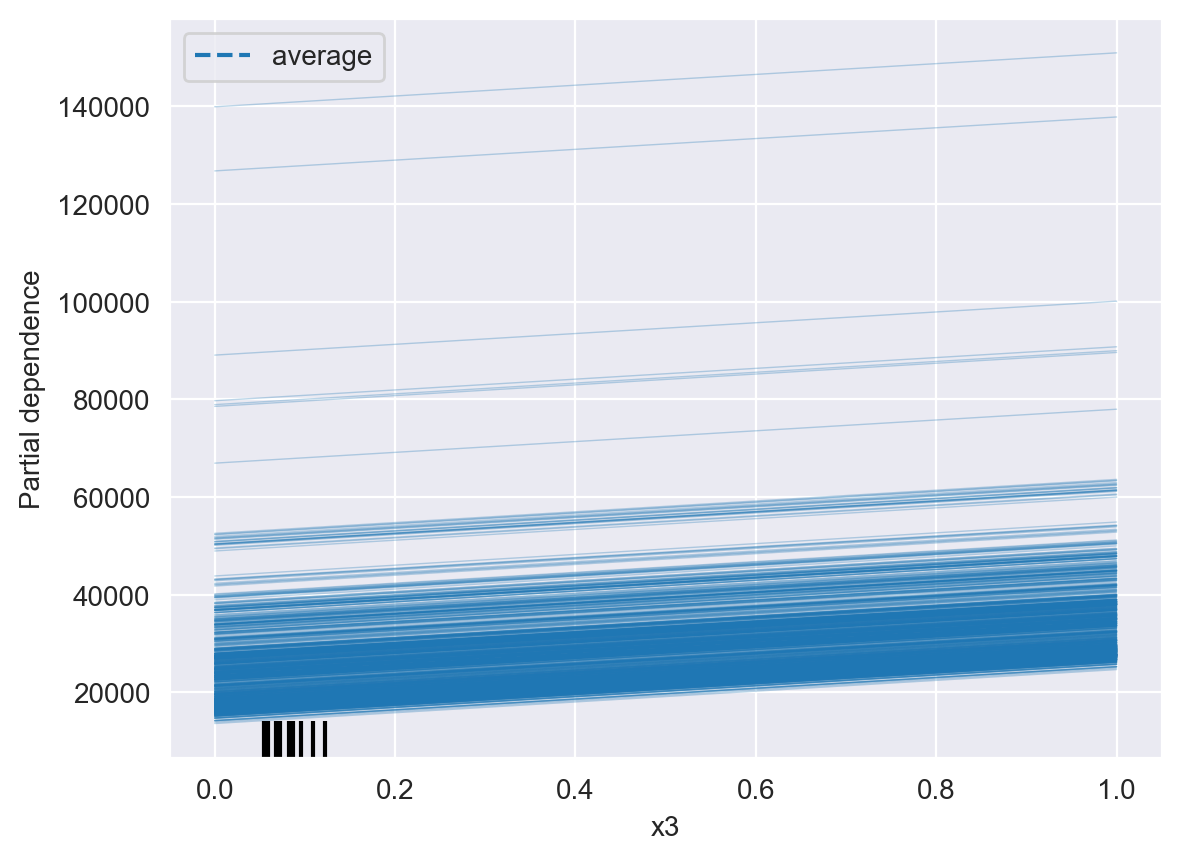

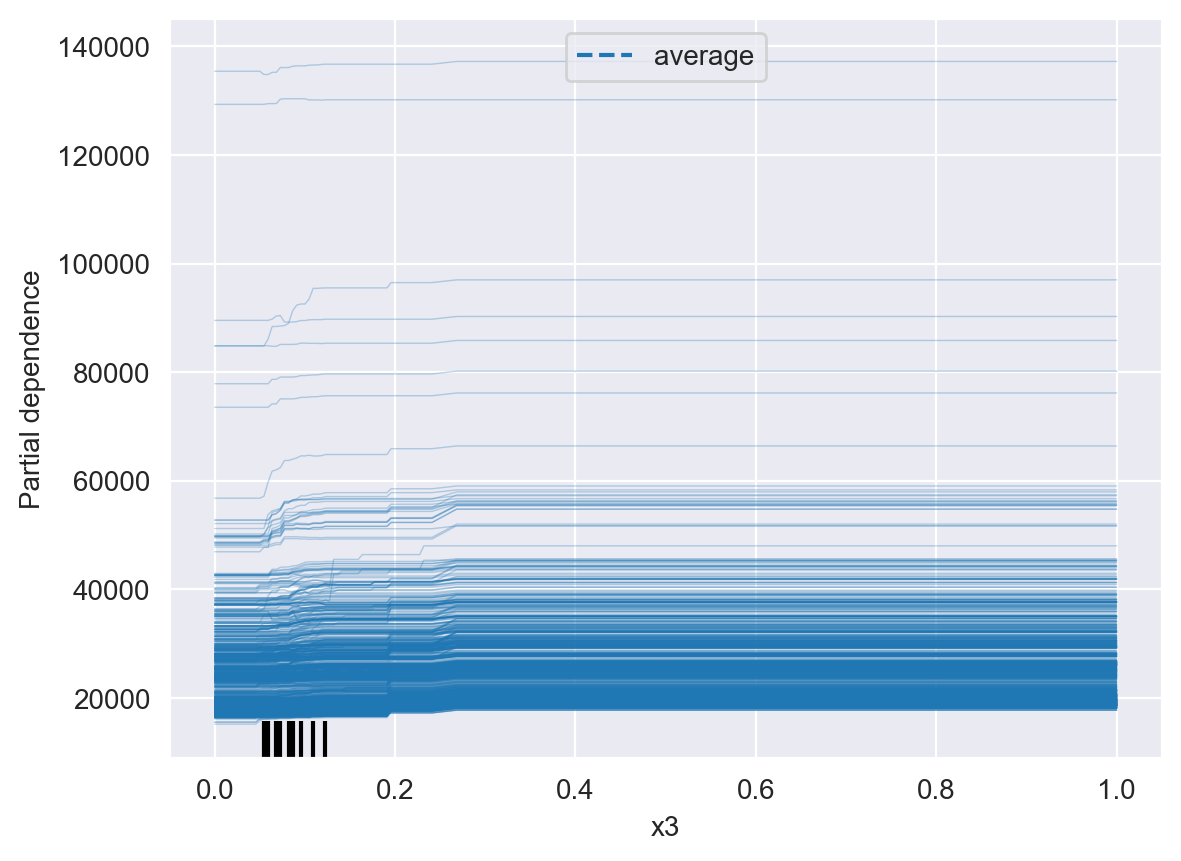

In [28]:
plot_pdp_ice(models, X_train_mm, feature_idx, feature_1)

In [29]:
X_train_outliers = add_outliers(X_train, feature_1)

X_train_outliers_mm = preprocessor_minmax.transform(X_train_outliers)


Linear - PDP + ICE для floor (outliers)

Boosting - PDP + ICE для floor (outliers)


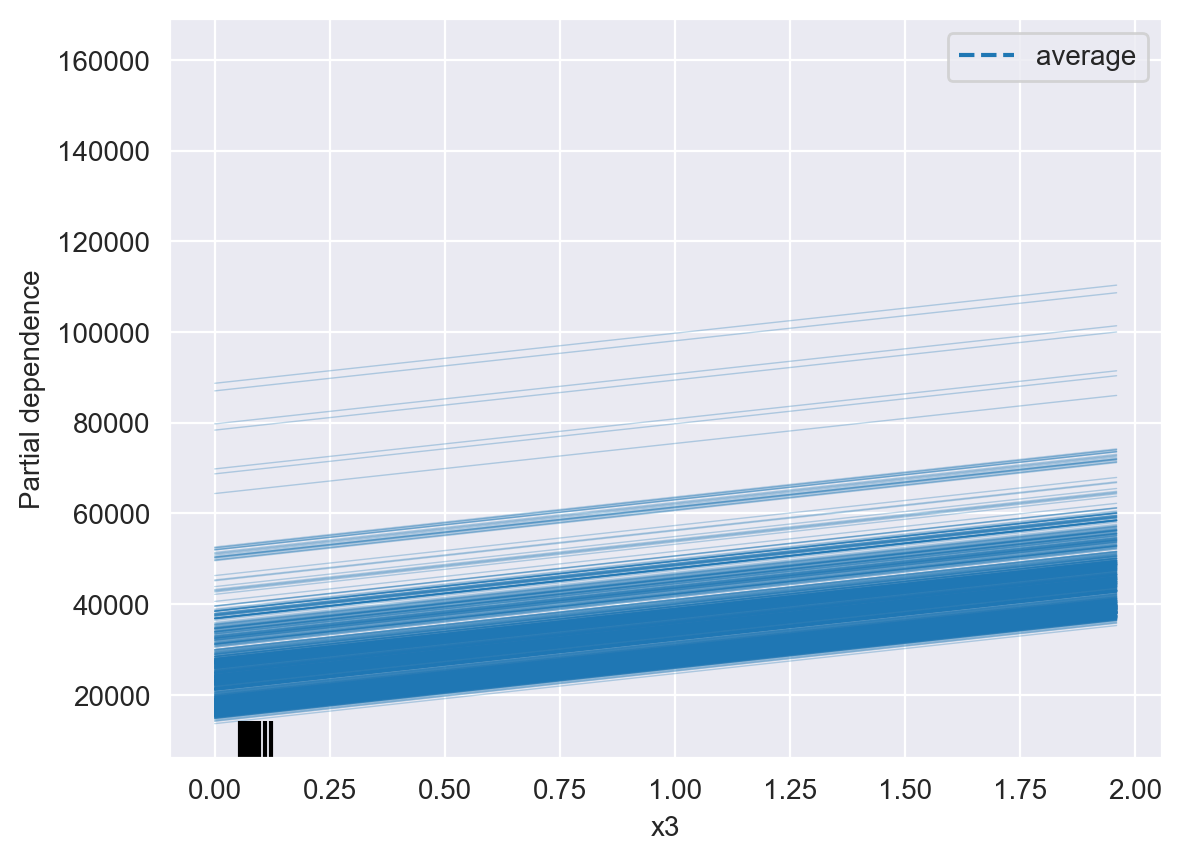

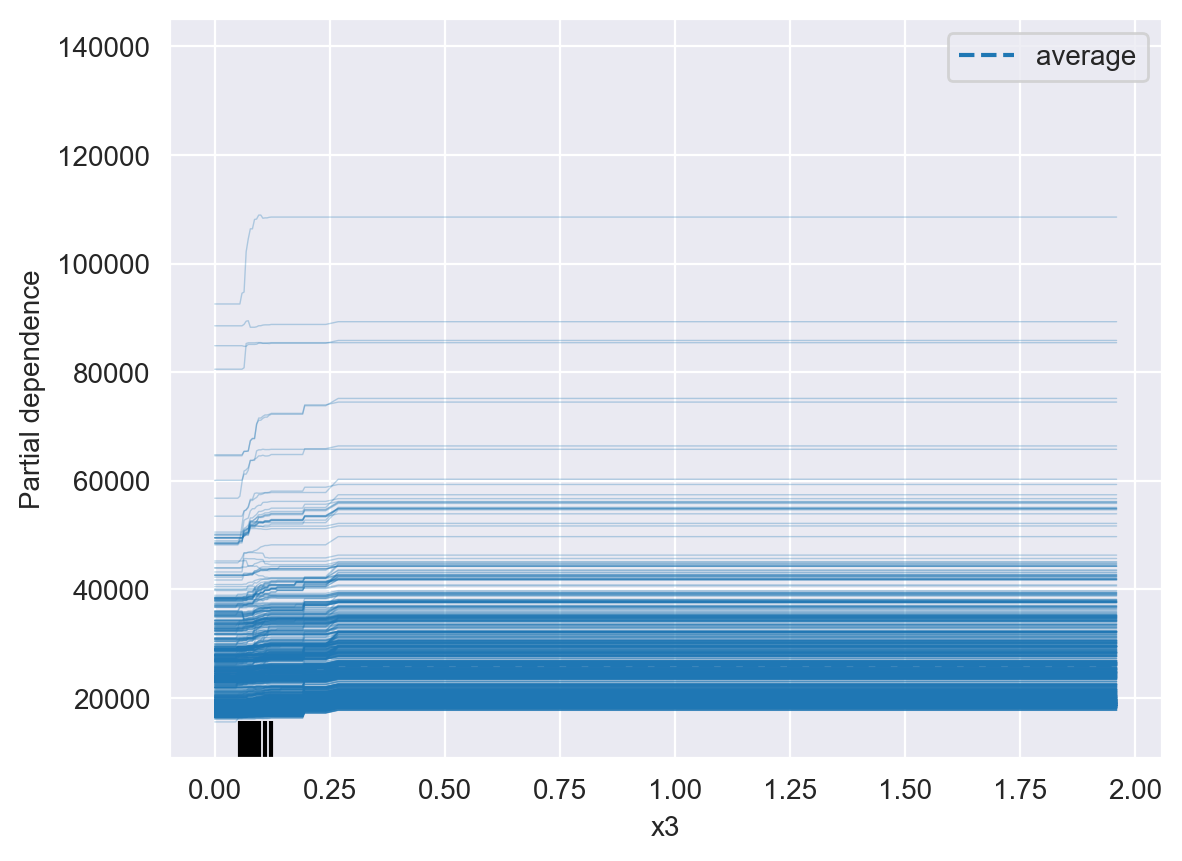

In [30]:
plot_pdp_ice(models, X_train_outliers_mm, feature_idx, feature_1 + " (outliers)")


Linear - PDP + ICE для square

Boosting - PDP + ICE для square

Linear - PDP + ICE для square (outliers)

Boosting - PDP + ICE для square (outliers)


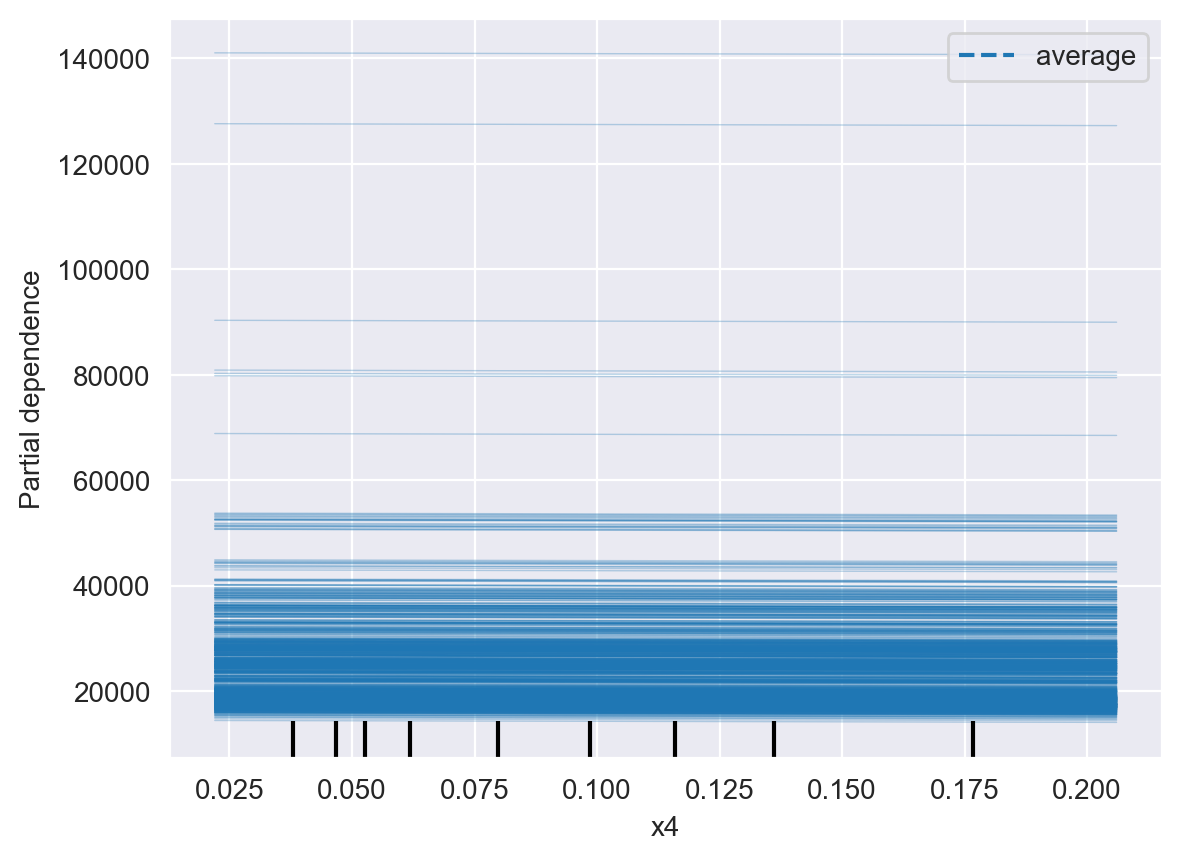

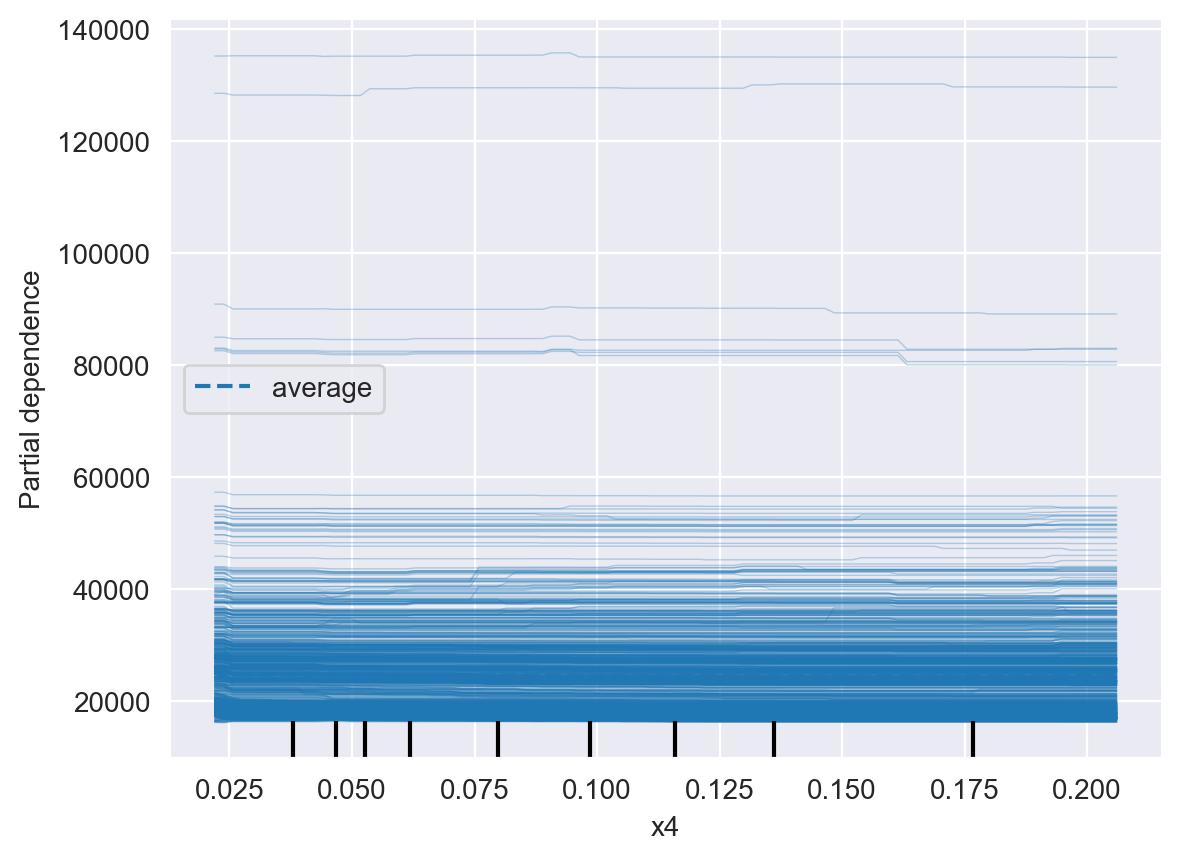

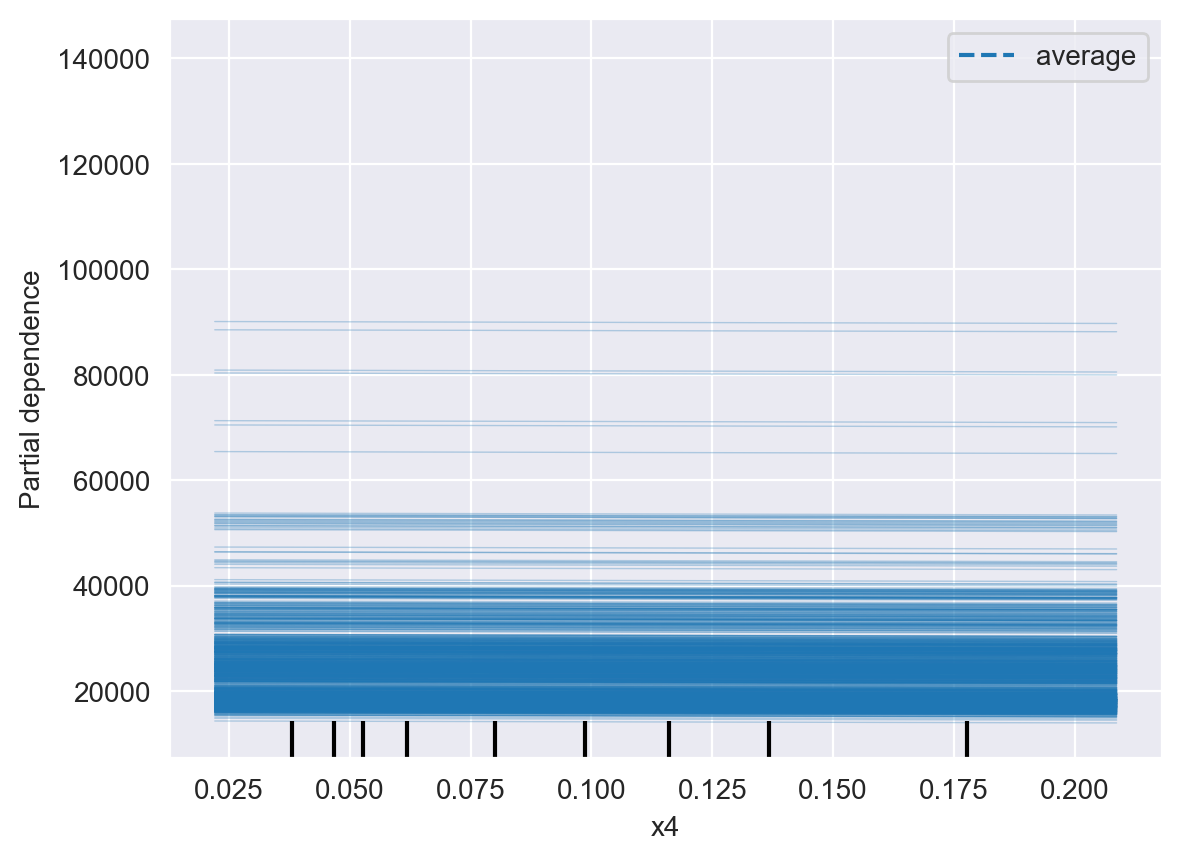

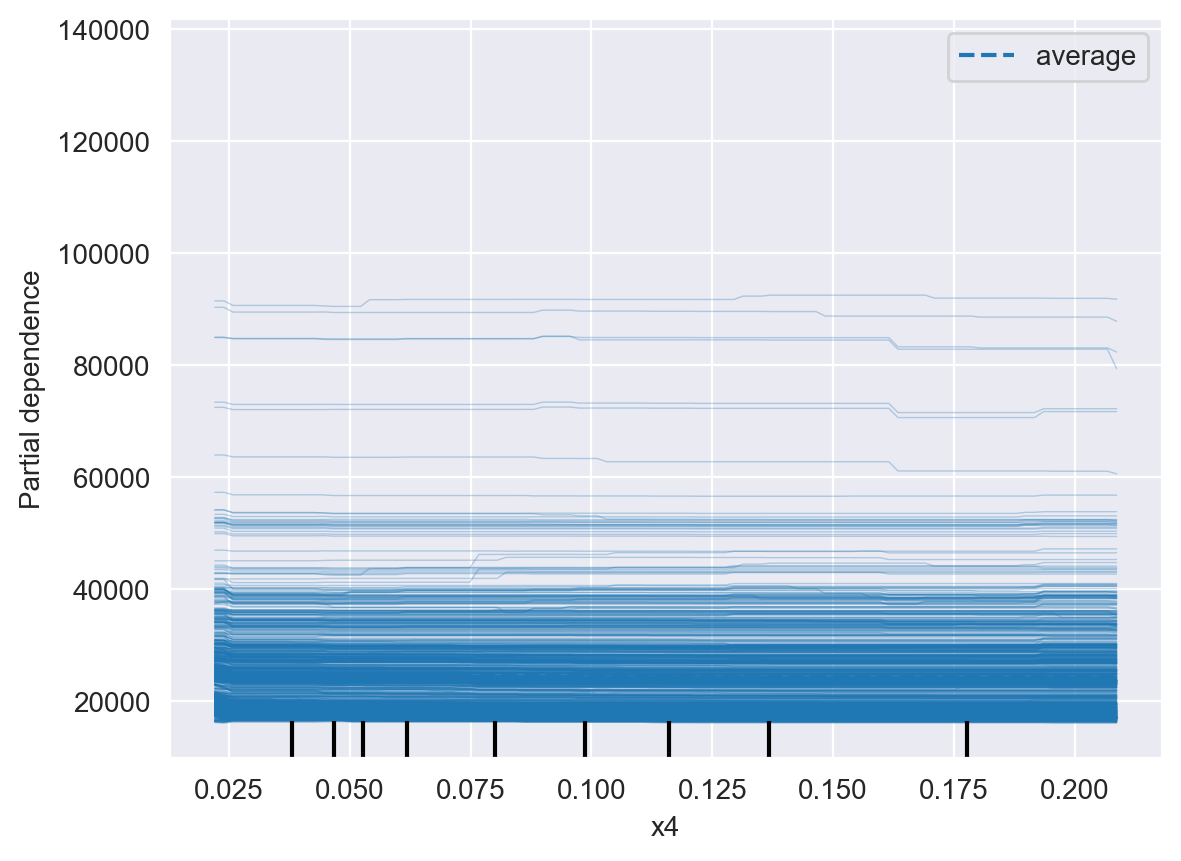

In [31]:
feature_idx, _ = get_feature_index(
    feature_2,
    numerical_cols,
    categorical_cols,
    preprocessor_minmax
)

plot_pdp_ice(models, X_train_mm, feature_idx, feature_2)

X_train_outliers = add_outliers(X_train, feature_2)
X_train_outliers_mm = preprocessor_minmax.transform(X_train_outliers)

plot_pdp_ice(models, X_train_outliers_mm, feature_idx, feature_2 + " (outliers)")


## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

In [32]:
def get_base_value(X_train, feature_name, mode='median'):
    if mode == 'median':
        return X_train[feature_name].median()
    elif mode == 'mean':
        return X_train[feature_name].mean()
    else:
        raise ValueError("mode должен быть 'median' или 'mean'")

In [33]:
def interpolate_values(start, end, n_steps=20):
    return np.linspace(start, end, n_steps)

In [35]:
def compute_trajectory(model, preprocessor, x_row, feature_name, base_value, n_steps=20):
    x_current = x_row.copy()
    
    start_value = x_current[feature_name]
    values = interpolate_values(start_value, base_value, n_steps)
    
    preds = []
    
    for v in values:
        x_temp = x_current.copy()
        x_temp[feature_name] = v
        
        x_transformed = preprocessor.transform(pd.DataFrame([x_temp]))
        pred = model.predict(x_transformed)[0]
        
        preds.append(pred)
    
    return values, preds

In [36]:
import matplotlib.pyplot as plt

def plot_trajectories(models, preprocessor, X_test, X_train, feature_name, n_objects=20, n_steps=20):
    
    sample = X_test.sample(n_objects, random_state=42)
    
    base_value = get_base_value(X_train, feature_name, mode='median')
    
    for model_name, model in models.items():
        plt.figure()
        
        print(f"\n{model_name} — признак: {feature_name}")
        
        for _, row in sample.iterrows():
            values, preds = compute_trajectory(
                model,
                preprocessor,
                row,
                feature_name,
                base_value,
                n_steps
            )
            
            plt.plot(values, preds, alpha=0.5)
        
        plt.axvline(base_value, linestyle='--')
        plt.title(f"{model_name}: trajectory for {feature_name}")
        plt.xlabel(feature_name)
        plt.ylabel("prediction")
        plt.show()


Linear — признак: floor


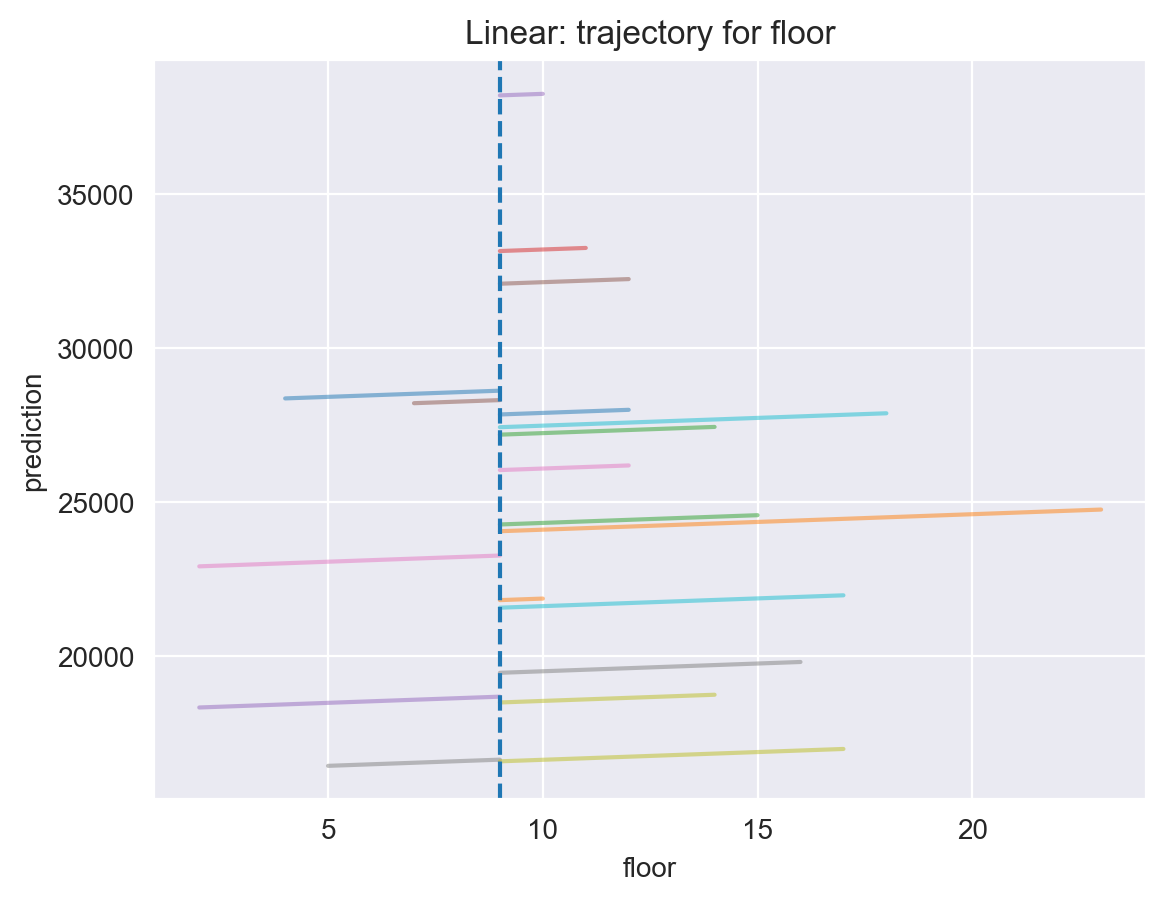


Boosting — признак: floor


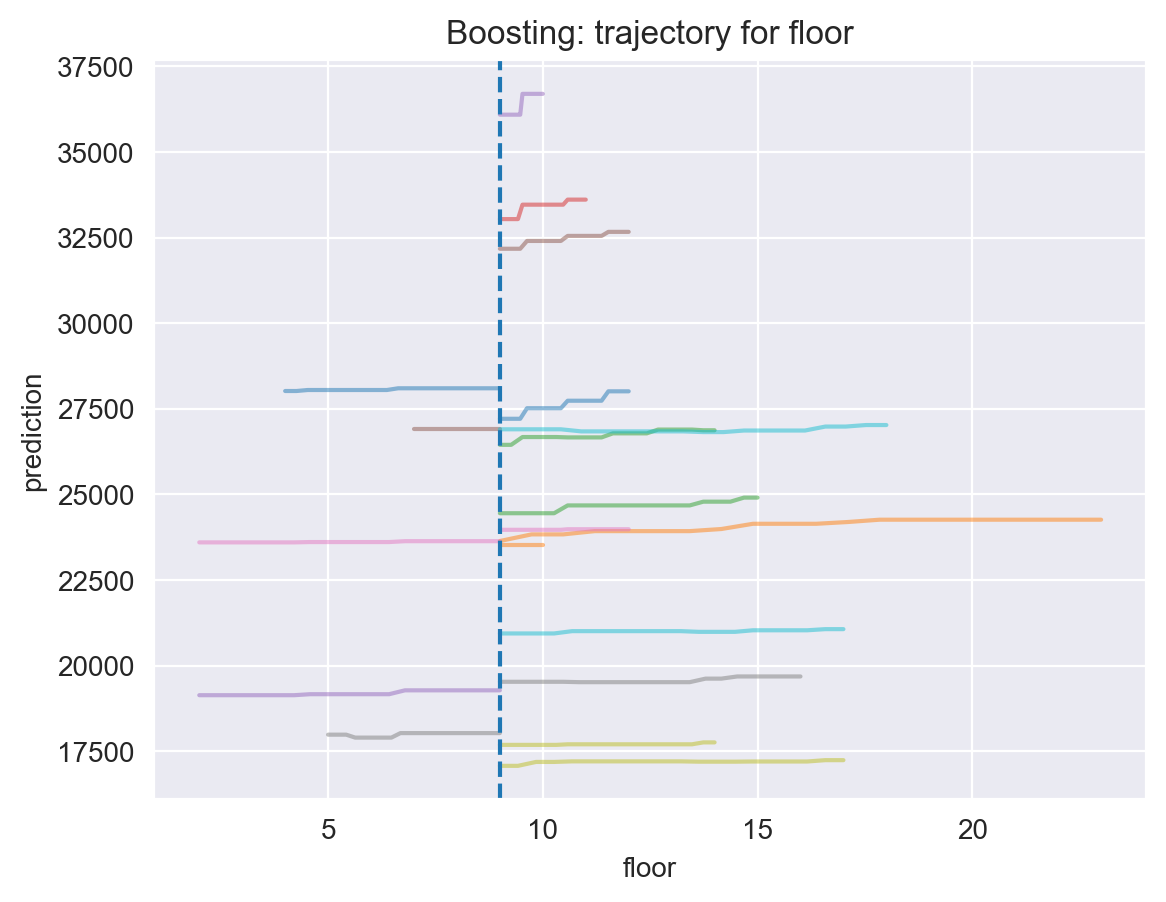

In [37]:
feature_1 = 'floor'

plot_trajectories(
    models,
    preprocessor_minmax,
    X_test,
    X_train,
    feature_1
)


Linear — признак: square


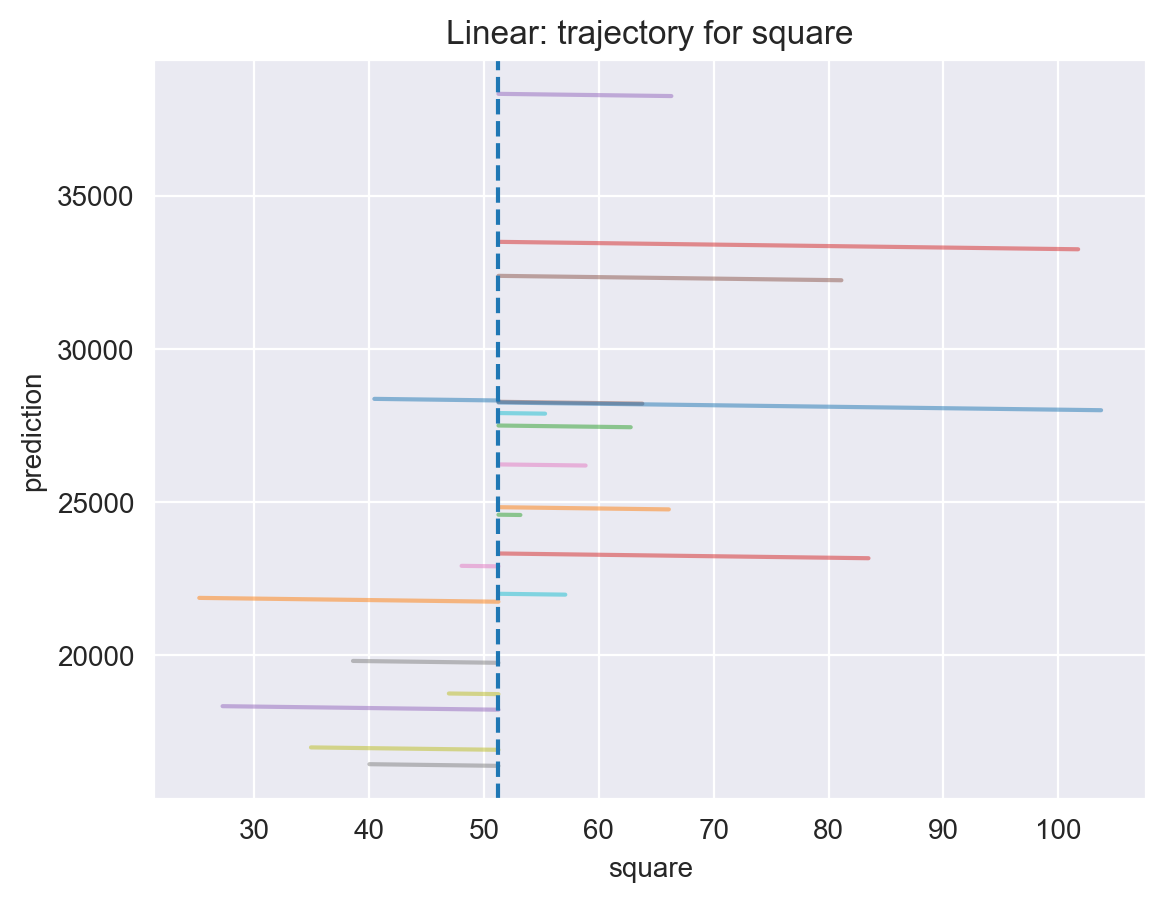


Boosting — признак: square


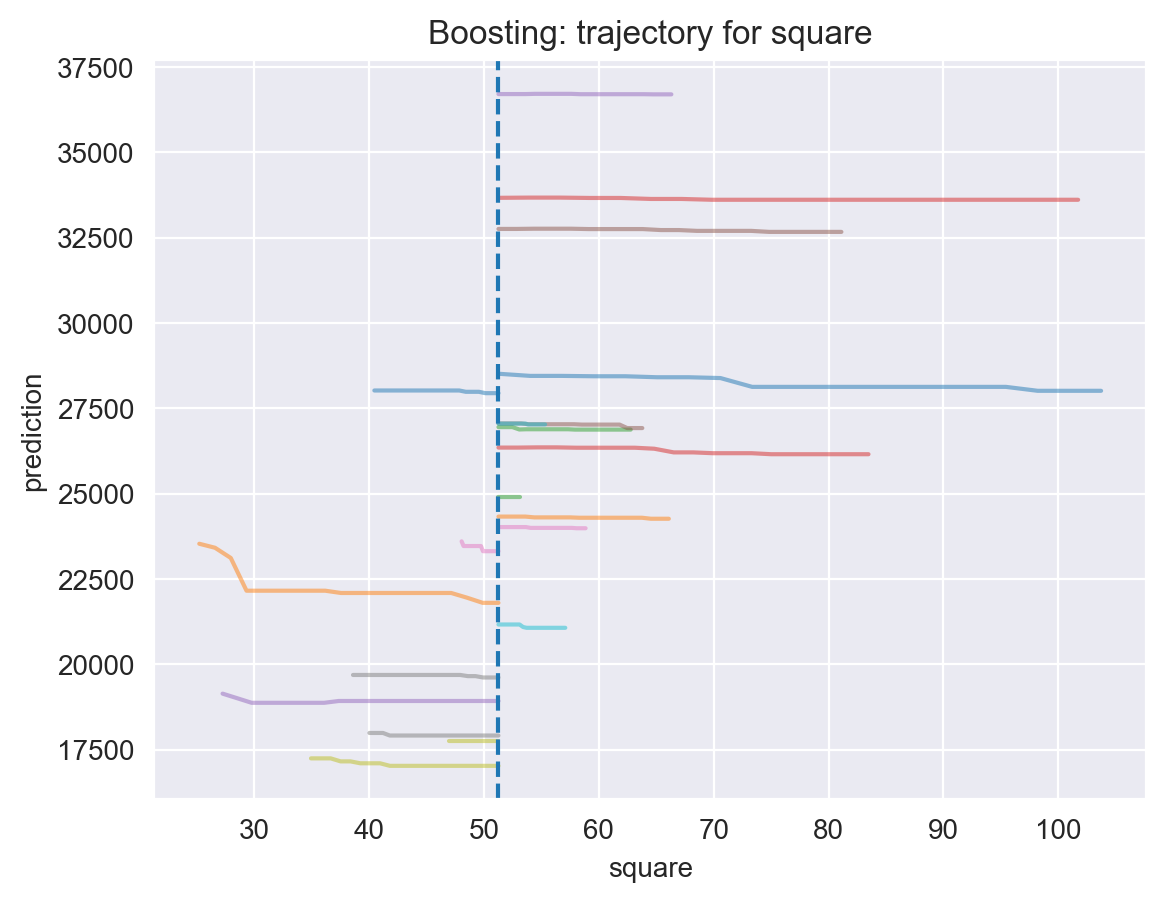

In [38]:
feature_2 = 'square'

plot_trajectories(
    models,
    preprocessor_minmax,
    X_test,
    X_train,
    feature_2
)

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [39]:
class ALEModelWrapper:
    def __init__(self, model, preprocessor):
        self.model = model
        self.preprocessor = preprocessor
    
    def predict(self, X):
        X_transformed = self.preprocessor.transform(X)
        return self.model.predict(X_transformed)

In [40]:
from PyALE import ale

In [41]:
import matplotlib.pyplot as plt

def plot_ale(models, preprocessor, X_train, feature_name, bins=20):
    
    X_sample = X_train.sample(2000, random_state=42) if len(X_train) > 2000 else X_train
    
    for model_name, model in models.items():
        print(f"\n{model_name} — ALE для {feature_name}")
        
        wrapped_model = ALEModelWrapper(model, preprocessor)
        
        plt.figure()
        
        ale_eff = ale(
            X=X_sample,
            model=wrapped_model, 
            feature=[feature_name],
            grid_size=bins,
            include_CI=True
        )
        
        plt.title(f"{model_name} ALE: {feature_name}")
        plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.



Linear — ALE для floor


<Figure size 640x480 with 0 Axes>

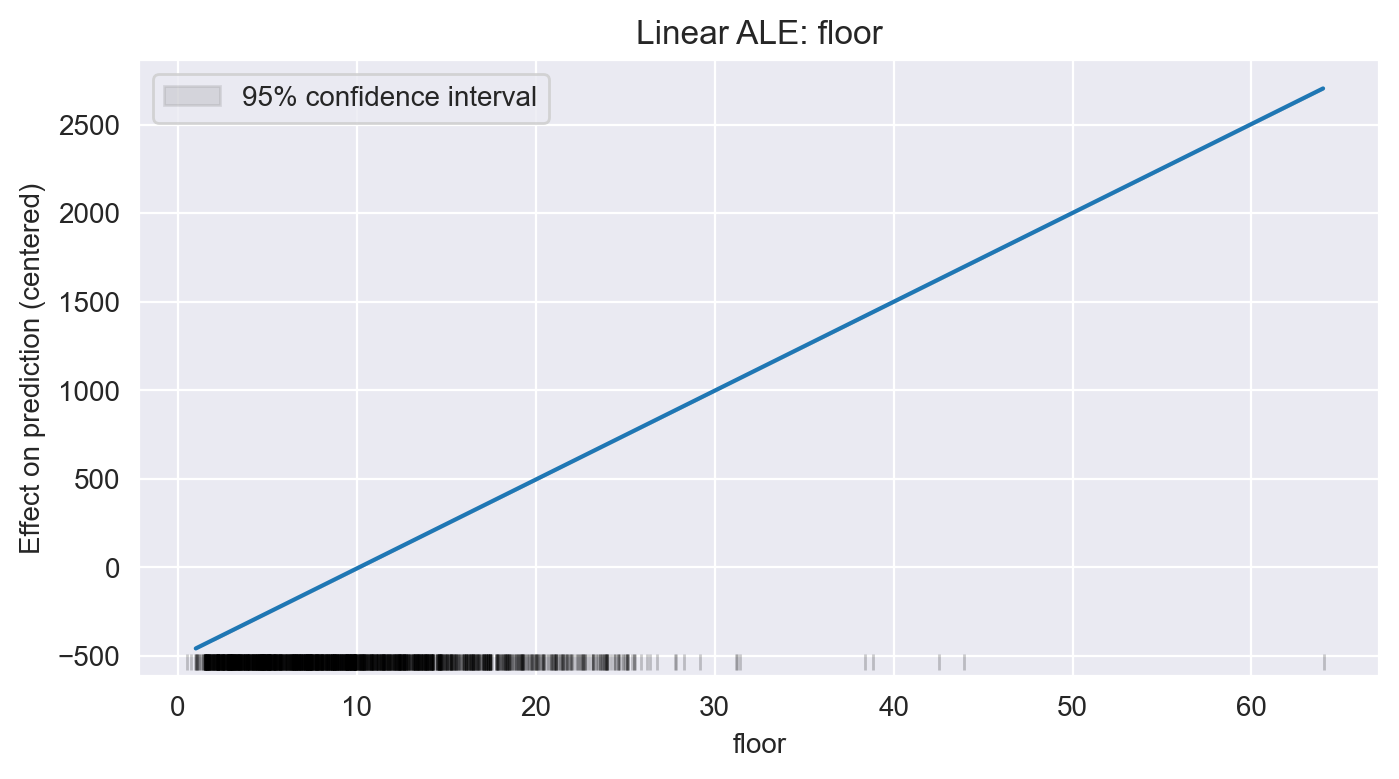

PyALE._ALE_generic:INFO: Continuous feature detected.



Boosting — ALE для floor


<Figure size 640x480 with 0 Axes>

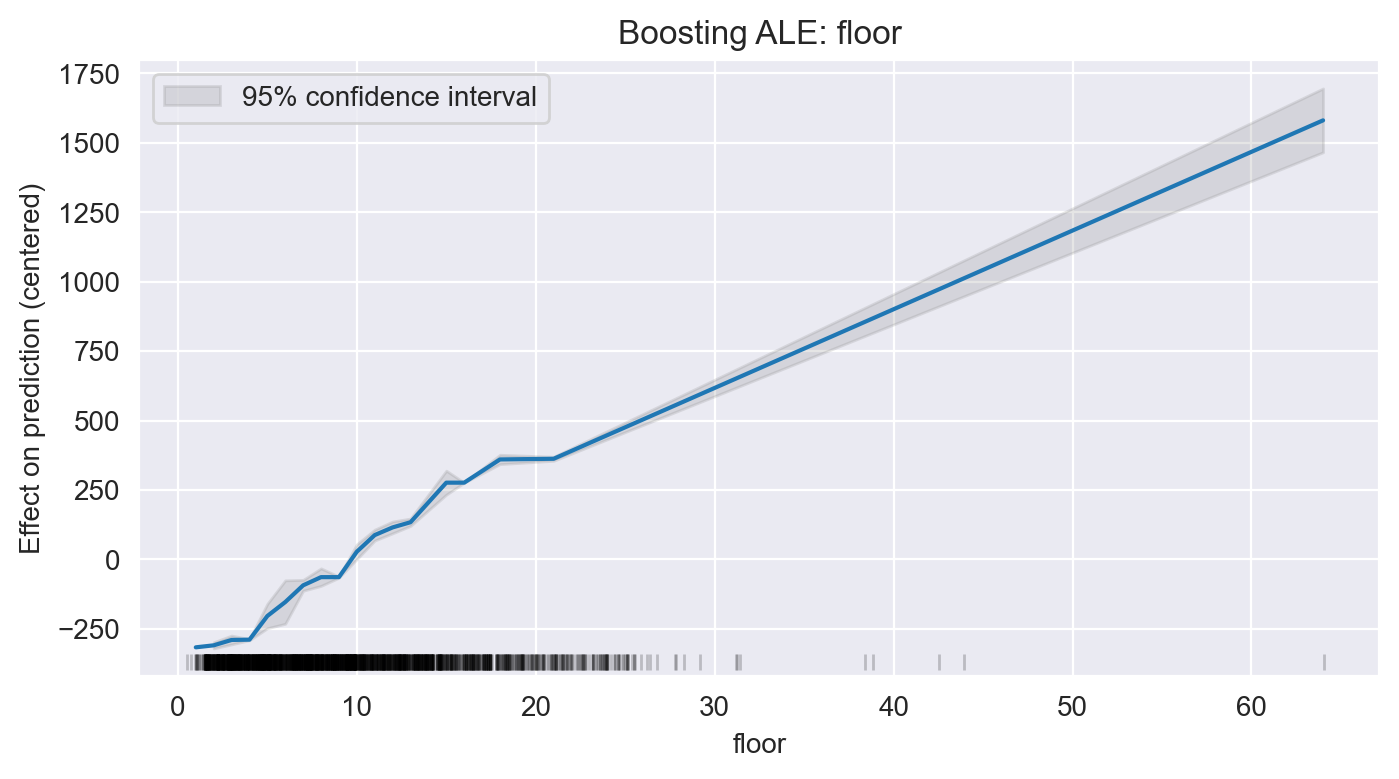

In [42]:
feature_1 = 'floor'

plot_ale(
    models,
    preprocessor_minmax,
    X_train,
    feature_1,
    bins=20
)

PyALE._ALE_generic:INFO: Continuous feature detected.



Linear — ALE для square


<Figure size 640x480 with 0 Axes>

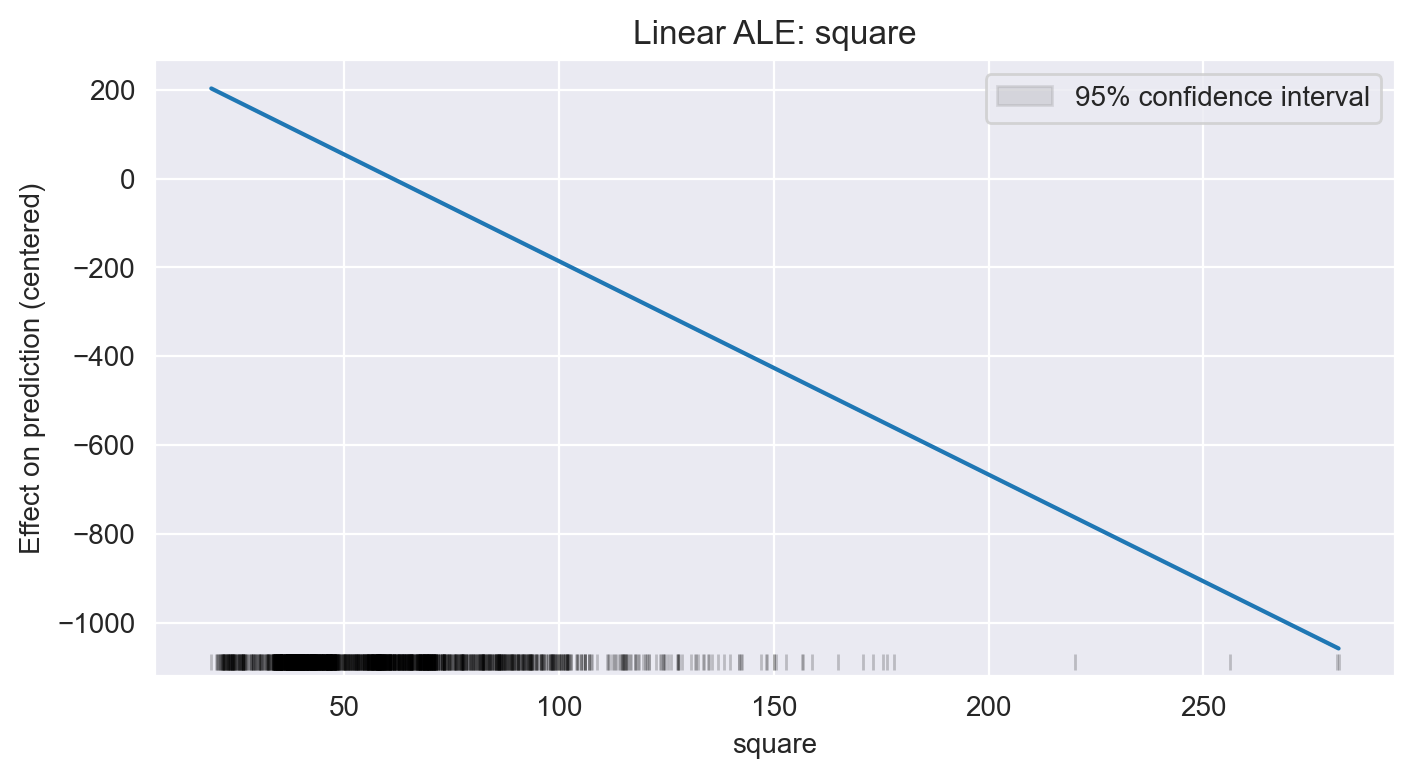

PyALE._ALE_generic:INFO: Continuous feature detected.



Boosting — ALE для square


<Figure size 640x480 with 0 Axes>

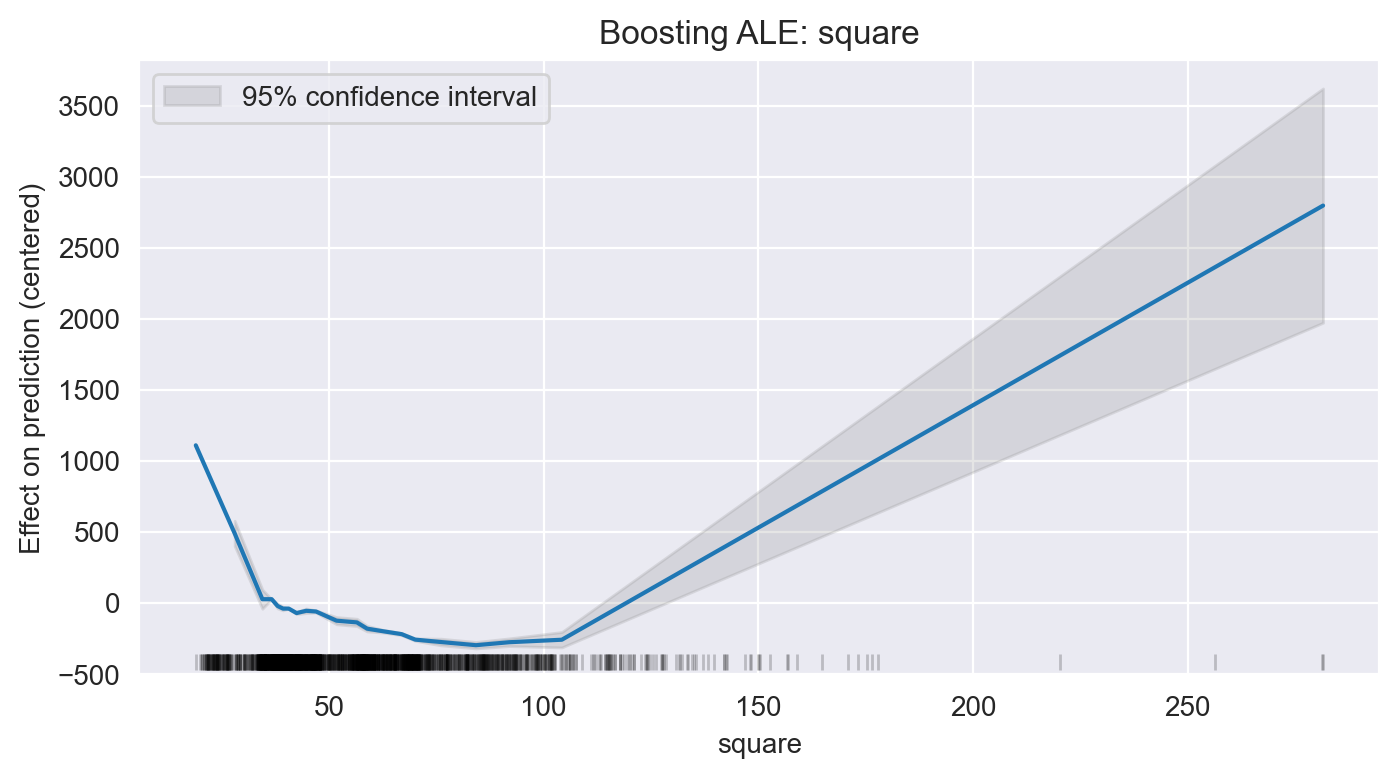

In [43]:
feature_2 = 'square'

plot_ale(
    models,
    preprocessor_minmax,
    X_train,
    feature_2,
    bins=20
)

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [44]:
from sklearn.inspection import permutation_importance

def compute_permutation_importance(model, X_test, y_test, feature_names, n_repeats=10):
    
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )
    
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return importances

In [45]:
def get_feature_names(preprocessor, numerical_cols, categorical_cols):
    cat_features = preprocessor.named_transformers_['cat'] \
        .named_steps['onehot'].get_feature_names_out(categorical_cols)
    
    return list(numerical_cols) + list(cat_features)

In [46]:
def permutation_experiment(models, X_test, y_test, feature_names, repeats_list=[5, 10, 30]):
    
    results = {}
    
    for model_name, model in models.items():
        print(model_name)
        
        results[model_name] = {}
        
        for n in repeats_list:
            print(f"\n n_repeats = {n}")
            
            imp = compute_permutation_importance(
                model,
                X_test,
                y_test,
                feature_names,
                n_repeats=n
            )
            
            print(imp.head(5))
            
            results[model_name][n] = imp
    
    return results

In [47]:
import matplotlib.pyplot as plt

def plot_importance_stability(results, model_name, feature, repeats_list):
    
    means = []
    stds = []
    
    for n in repeats_list:
        df = results[model_name][n]
        row = df[df["feature"] == feature]
        
        means.append(row["importance_mean"].values[0])
        stds.append(row["importance_std"].values[0])
    
    plt.figure()
    
    plt.plot(repeats_list, means, marker='o', label='mean importance')
    plt.plot(repeats_list, stds, marker='o', linestyle='--', label='std')
    
    plt.xlabel("n_repeats")
    plt.ylabel("value")
    plt.title(f"{model_name} — {feature}")
    plt.legend()
    
    plt.show()

In [48]:
feature_names = get_feature_names(
    preprocessor_minmax,
    numerical_cols,
    categorical_cols
)

In [49]:
results = permutation_experiment(
    models,
    X_test_mm,
    y_test,
    feature_names,
    repeats_list=[5, 10, 30]
)

Linear

 n_repeats = 5
                                       feature  importance_mean  \
55       location_shop_product_w_mean_distance     15687.610971   
58   location_highway_crossing_w_mean_distance      7457.267261   
48        location_marketplace_w_mean_distance      5737.120177   
63          location_shop_alco_w_mean_distance      2356.679748   
126                            hc_name_cat_197      1660.707626   

     importance_std  
55       152.533375  
58        72.378291  
48        80.756830  
63        46.053411  
126       22.147622  

 n_repeats = 10
                                       feature  importance_mean  \
55       location_shop_product_w_mean_distance     15687.446586   
58   location_highway_crossing_w_mean_distance      7457.345033   
48        location_marketplace_w_mean_distance      5762.700148   
63          location_shop_alco_w_mean_distance      2358.540998   
126                            hc_name_cat_197      1666.261248   

     importance_std  


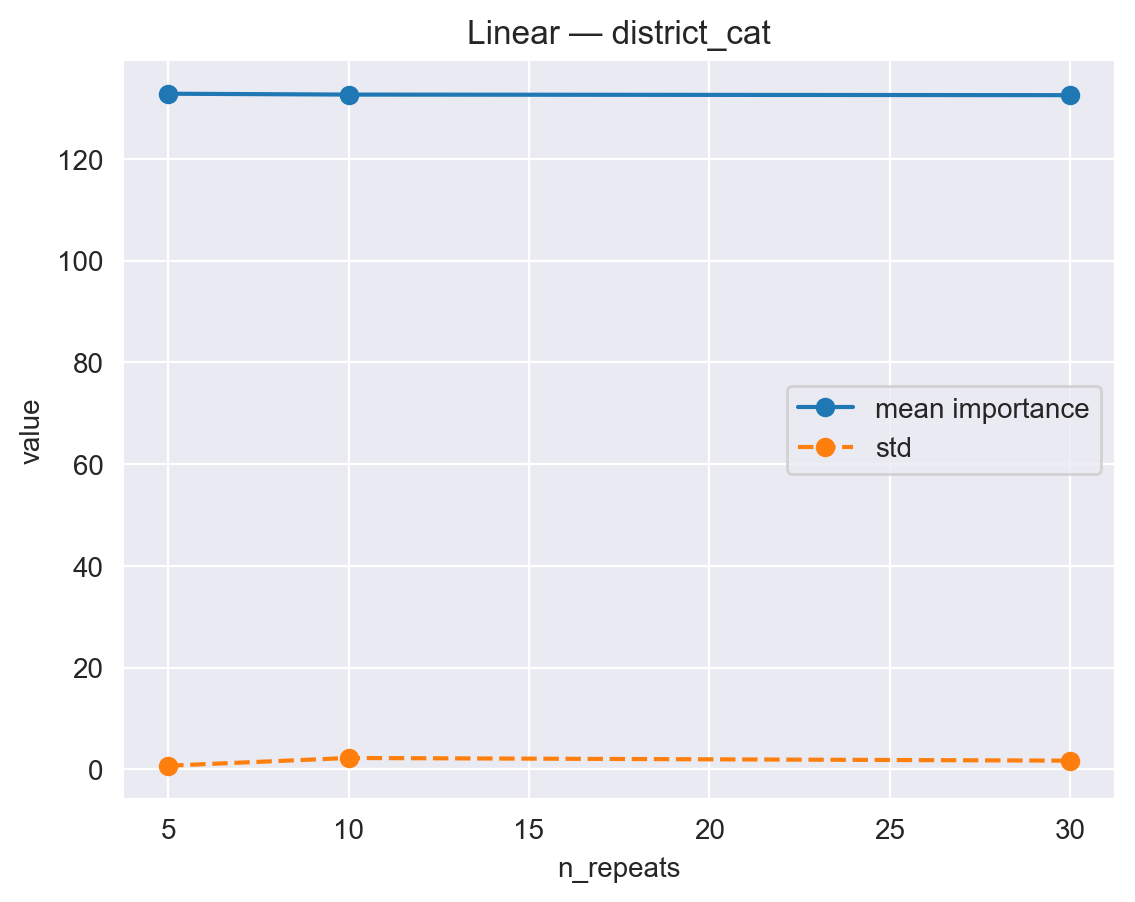

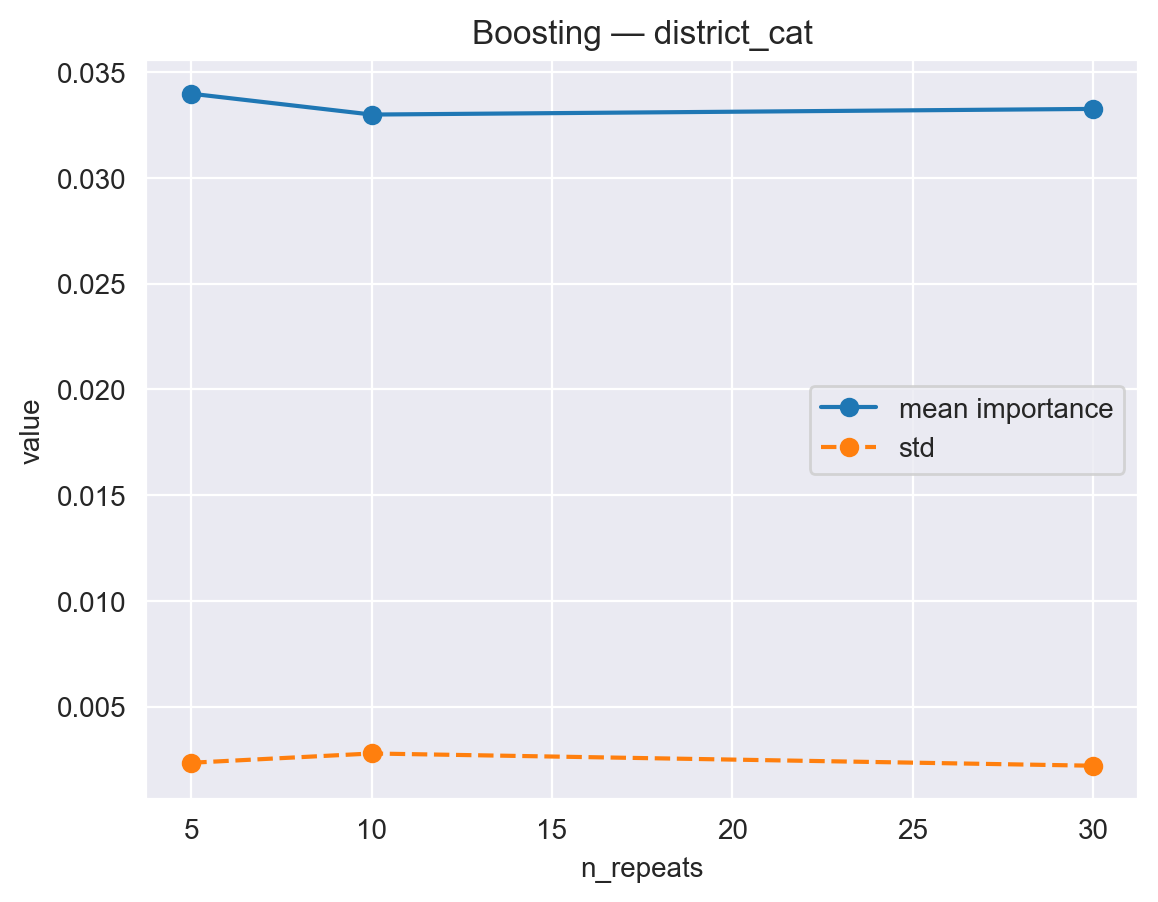

In [50]:
plot_importance_stability(results, "Linear", feature_names[0], [5, 10, 30])
plot_importance_stability(results, "Boosting", feature_names[0], [5, 10, 30])

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [51]:
numerical_only = numerical_cols.copy()

In [52]:
from sklearn.metrics import mean_absolute_percentage_error

def compute_baseline_mape(model, preprocessor, X_test, y_test):
    X_test_tr = preprocessor.transform(X_test)
    pred = model.predict(X_test_tr)
    return mean_absolute_percentage_error(y_test, pred) * 100

In [53]:
def perturb_feature(X, feature, base_value, beta):
    X_new = X.copy()
    
    X_new[feature] = (1 - beta) * X_new[feature] + beta * base_value
    
    return X_new

In [54]:
def compute_feature_importance_beta(model, preprocessor, X_test, y_test, 
                                    feature, base_value, beta, baseline_mape):
    
    X_perturbed = perturb_feature(X_test, feature, base_value, beta)
    
    X_tr = preprocessor.transform(X_perturbed)
    pred = model.predict(X_tr)
    
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    
    return mape - baseline_mape

In [55]:
def compute_importance_for_all_features(model, preprocessor, X_train, X_test, y_test, 
                                        numerical_features, beta):
    
    baseline_mape = compute_baseline_mape(model, preprocessor, X_test, y_test)
    
    importances = []
    
    for feature in numerical_features:
        base_value = X_train[feature].median()
        
        imp = compute_feature_importance_beta(
            model,
            preprocessor,
            X_test,
            y_test,
            feature,
            base_value,
            beta,
            baseline_mape
        )
        
        importances.append((feature, imp))
    
    df = pd.DataFrame(importances, columns=["feature", "importance"])
    df = df.sort_values("importance", ascending=False)
    
    return df

In [56]:
def beta_experiment(model, preprocessor, X_train, X_test, y_test, 
                    numerical_features, betas=[0.25, 0.5, 0.75, 1.0]):
    
    results = {}
    
    for beta in betas:
        print(f"beta = {beta}")
        
        df = compute_importance_for_all_features(
            model,
            preprocessor,
            X_train,
            X_test,
            y_test,
            numerical_features,
            beta
        )
        
        print(df.head(5))
        
        results[beta] = df
    
    return results

In [57]:
import matplotlib.pyplot as plt

def plot_beta_importance(results, feature):
    
    betas = sorted(results.keys())
    values = []
    
    for b in betas:
        df = results[b]
        val = df[df["feature"] == feature]["importance"].values[0]
        values.append(val)
    
    plt.figure()
    plt.plot(betas, values, marker='o')
    plt.xlabel("beta")
    plt.ylabel("importance (ΔMAPE)")
    plt.title(f"Importance vs beta: {feature}")
    plt.show()

In [58]:
boosting_model = models["Boosting"]

In [59]:
results_beta = beta_experiment(
    boosting_model,
    preprocessor_minmax,
    X_train,
    X_test,
    y_test,
    numerical_only
)

beta = 0.25
                                        feature  importance
30                location_town_w_mean_distance    0.928089
0                                  district_cat    0.281067
59  location_public_transport_stop_position_cnt    0.223204
1                                    corpus_cat    0.191479
6                      location_logs_count_mean    0.171463
beta = 0.5
                                        feature  importance
30                location_town_w_mean_distance    0.928089
6                      location_logs_count_mean    0.590533
0                                  district_cat    0.544421
59  location_public_transport_stop_position_cnt    0.422266
69    location_amenity_pharmacy_w_mean_distance    0.379263
beta = 0.75
                                      feature  importance
6                    location_logs_count_mean    0.960415
68                       location_college_cnt    0.955800
30              location_town_w_mean_distance    0.928089
69  location_

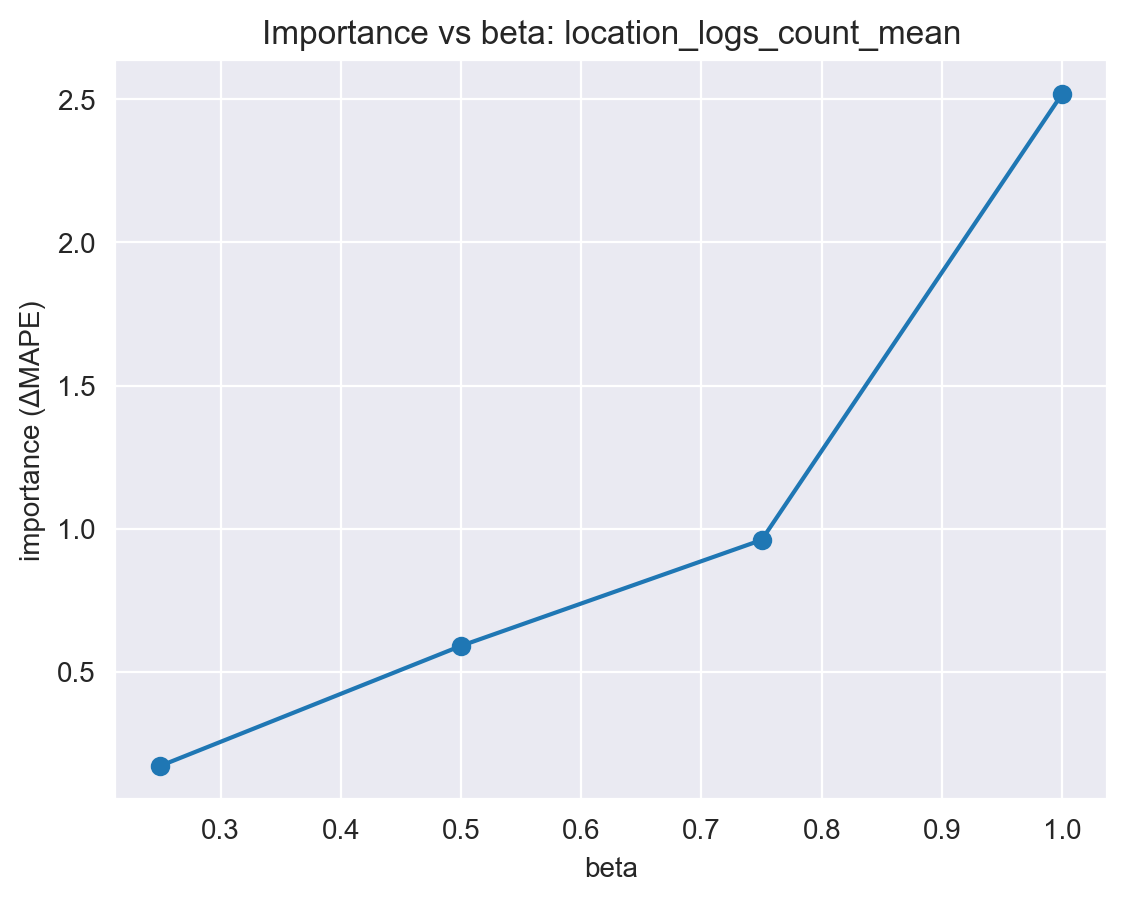

In [60]:
top_feature = results_beta[1.0].iloc[0]["feature"]

plot_beta_importance(results_beta, top_feature)

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



In [71]:
from sklearn.linear_model import Lasso, Ridge

In [82]:
class LIME:
    def __init__(self, train_data, kernel, kernel_width=3.0, n_samples=5000, random_state=42):
        self.train_data = np.asarray(train_data)
        self.kernel = kernel
        self.kernel_width = kernel_width
        self.n_samples = n_samples
        self.random_state = np.random.RandomState(random_state)
        
        self.binary_mask = np.all(
            (self.train_data == 0) | (self.train_data == 1), axis=0
        )
        
        self.stds = np.std(self.train_data, axis=0)
        
        self.categorical_masks = {}
        for j in range(self.train_data.shape[1]):
            if not self.binary_mask[j]:
                unique_vals, counts = np.unique(self.train_data[:, j], return_counts=True)
                if len(unique_vals) < 10:  
                    self.categorical_masks[j] = (unique_vals, counts / counts.sum())

    def _generate_samples(self, instance):
        instance = np.asarray(instance).reshape(-1)
        n_features = len(instance)
        samples = np.zeros((self.n_samples, n_features))
        
        for j in range(n_features):
            if j in self.categorical_masks:
                unique_vals, probs = self.categorical_masks[j]
                samples[:, j] = self.random_state.choice(
                    unique_vals, 
                    size=self.n_samples, 
                    p=probs
                )
            elif self.binary_mask[j]:
                p = instance[j]
                p = np.clip(p + self.random_state.normal(0, 0.05), 0, 1)
                samples[:, j] = self.random_state.binomial(1, p, size=self.n_samples)
            else:
                scale = self.stds[j] * 0.2 + 1e-6
                samples[:, j] = self.random_state.normal(
                    loc=instance[j],
                    scale=scale,
                    size=self.n_samples
                )
                min_val = np.min(self.train_data[:, j])
                max_val = np.max(self.train_data[:, j])
                samples[:, j] = np.clip(samples[:, j], min_val, max_val)
        
        return samples

    def explain(self, instance, predict_fn, num_features=5, model_type='lasso', alpha=0.01):
        instance = np.asarray(instance).reshape(-1)
        
        samples = self._generate_samples(instance)
        
        preds = predict_fn(samples)
        if preds.ndim > 1:
            preds = preds[:, 1]
        
        distances = np.sqrt(((samples - instance) ** 2).sum(axis=1))
        
        weights = self.kernel(distances, self.kernel_width)
        
        weights = weights / (np.max(weights) + 1e-8)
        
        if model_type == 'lasso':
            model = Lasso(alpha=alpha, max_iter=10000, random_state=self.random_state)
        elif model_type == 'ridge':
            model = Ridge(alpha=alpha, random_state=self.random_state)
        else:
            model = LinearRegression()
        
        try:
            model.fit(samples, preds, sample_weight=weights)
            coefs = model.coef_
        except Exception as e:
            print(f"Ошибка при обучении {model_type}: {e}")
            model = Ridge(alpha=0.1)
            model.fit(samples, preds, sample_weight=weights)
            coefs = model.coef_
        
        top_idx = np.argsort(-np.abs(coefs))[:num_features]
        
        explanation = {
            f"feature_{i}": coefs[i]
            for i in top_idx
        }
        
        return explanation, model

In [83]:
def kernel(d, kernel_width):
    return np.exp(-(d ** 2) / (kernel_width ** 2))

In [84]:
X_train_lime = X_train_scaled
X_test_lime = X_test_scaled

In [85]:
def predict_fn_lime(X):
    return boosting_model.predict(X)

In [86]:
feature_names = get_feature_names(
    preprocessor_minmax,
    numerical_cols,
    categorical_cols
)

In [87]:
lime = LIME(X_train_lime, kernel)

for i in range(3):
    instance = X_test_lime[i]
    
    explanation, _ = lime.explain(instance, predict_fn_lime)
    
    explanation_named = {
        feature_names[int(k.split('_')[1])]: v
        for k, v in explanation.items()
    }
    
    print(f"Объект {i}:")
    for k, v in explanation_named.items():
        print(f"{k}: {v:.4f}")

Объект 0:
class_cat_2581: 40191.9129
hc_name_cat_209: -3885.2454
location_leisure_cnt: 3785.8012
hc_name_cat_90: -3410.7117
hc_name_cat_275: -2372.8841
Объект 1:
class_cat_2581: 47819.8083
class_cat_97865: -8993.8929
location_max_levels_max: 5177.3892
hc_name_cat_117: 2784.2652
class_cat_27353: 2207.1545
Объект 2:
class_cat_2581: 37904.1869
hc_name_cat_90: -4736.2508
hc_name_cat_387: 2725.1920
location_marketplace_cnt: 1414.4849
hc_name_cat_426: 1370.3395


Тесты

In [92]:
def test_lime_runs():
    explanation, model = lime.explain(X_test_lime[0], predict_fn_lime)
    
    assert isinstance(explanation, dict)
    assert model is not None


def test_num_features_limit():
    explanation, _ = lime.explain(X_test_lime[0], predict_fn_lime, num_features=3)
    
    assert len(explanation) <= 3


def test_no_nan_in_coeffs():
    explanation, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    
    for v in explanation.values():
        assert not np.isnan(v)
        assert np.isfinite(v)


def test_coefficients_not_all_zero():
    explanation, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    
    values = np.array(list(explanation.values()))
    assert not np.allclose(values, 0)


def test_stability_same_instance():
    exp1, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    exp2, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    
    common = set(exp1.keys()) & set(exp2.keys())
    
    assert len(common) > 0


def test_different_instances_different_explanations():
    exp1, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    exp2, _ = lime.explain(X_test_lime[1], predict_fn_lime)
    
    assert exp1 != exp2


def test_n_samples_effect():
    lime.n_samples = 500
    exp_small, _ = lime.explain(X_test_lime[0], predict_fn_lime)

    lime.n_samples = 5000
    exp_big, _ = lime.explain(X_test_lime[0], predict_fn_lime)

    assert isinstance(exp_small, dict)
    assert isinstance(exp_big, dict)
    assert exp_small != exp_big


def test_kernel_width_effect():
    lime.kernel_width = 0.5
    exp_small, _ = lime.explain(X_test_lime[0], predict_fn_lime)

    lime.kernel_width = 2.0
    exp_big, _ = lime.explain(X_test_lime[0], predict_fn_lime)

    assert exp_small != exp_big


def test_weights_not_degenerate():
    instance = X_test_lime[0]
    samples = lime._generate_samples(instance)

    distances = np.sqrt(((samples - instance) ** 2).sum(axis=1))
    weights = lime.kernel(distances, lime.kernel_width)

    assert not np.allclose(weights, 0)
    
    assert np.any(weights > 1e-6)


def test_sampling_shape():
    instance = X_test_lime[0]
    samples = lime._generate_samples(instance)
    
    assert samples.shape[0] == lime.n_samples
    assert samples.shape[1] == len(instance)


def test_predict_fn_shape():
    samples = lime._generate_samples(X_test_lime[0])
    preds = predict_fn_lime(samples)
    
    assert len(preds) == samples.shape[0]


def test_binary_features_sampling():
    instance = X_test_lime[0]
    samples = lime._generate_samples(instance)
    
    binary_mask = lime.binary_mask
    
    if np.any(binary_mask):
        binary_values = samples[:, binary_mask]
        assert np.all((binary_values == 0) | (binary_values == 1))

In [93]:
test_lime_runs()
test_binary_features_sampling()
test_predict_fn_shape()
test_sampling_shape()
test_weights_not_degenerate()
test_kernel_width_effect()
test_different_instances_different_explanations()
test_stability_same_instance()
test_coefficients_not_all_zero()
test_no_nan_in_coeffs()
test_num_features_limit()

Влияние n_samples 

In [89]:
for n in [500, 2000, 5000]:
    lime.n_samples = n
    
    explanation, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    
    print(f"n_samples = {n}")
    print(explanation)

n_samples = 500
{'feature_241': np.float64(-9203.925684739132), 'feature_23': np.float64(3903.0114641699874), 'feature_98': np.float64(-3657.4846949478556), 'feature_160': np.float64(-2081.0686469525667), 'feature_0': np.float64(2029.0042410662509)}
n_samples = 2000
{'feature_239': np.float64(40566.01432667776), 'feature_241': np.float64(-10698.174304812892), 'feature_134': np.float64(-4053.3413639151586), 'feature_23': np.float64(3703.8904848605944), 'feature_98': np.float64(-3438.4924564286925)}
n_samples = 5000
{'feature_23': np.float64(3830.9914845976773), 'feature_98': np.float64(-3753.392525995886), 'feature_160': np.float64(-2298.5723271612947), 'feature_0': np.float64(2097.3709687039254), 'feature_236': np.float64(1940.106589893298)}


Lasso vs LinearRegression

In [90]:
from sklearn.linear_model import LinearRegression

def explain_with_model(model_class):
    instance = X_test_lime[0]

    samples = lime._generate_samples(instance)
    preds = predict_fn_lime(samples)

    if preds.ndim > 1:
        preds = preds[:, 1]

    scaler = StandardScaler()
    samples_scaled = scaler.fit_transform(samples)
    instance_scaled = scaler.transform(instance.reshape(1, -1))

    distances = np.sqrt(((samples_scaled - instance_scaled) ** 2).sum(axis=1))
    weights = kernel(distances, lime.kernel_width)

    W = np.sqrt(weights)
    X_w = samples_scaled * W[:, None]
    y_w = preds * W

    model = model_class()
    model.fit(X_w, y_w)

    coefs = model.coef_
    top_idx = np.argsort(-np.abs(coefs))[:5]

    return {f"feature_{i}": coefs[i] for i in top_idx}


print("Lasso:")
print(explain_with_model(lambda: Lasso(alpha=0.001)))

print("LinearRegression:")
print(explain_with_model(LinearRegression))

Lasso:
{'feature_89': np.float64(-46944.2227952319), 'feature_84': np.float64(-35315.980663117894), 'feature_82': np.float64(-17617.48420895785), 'feature_141': np.float64(-16576.033022478965), 'feature_144': np.float64(-10374.12242568049)}
LinearRegression:
{'feature_128': np.float64(-2739869109.0292554), 'feature_162': np.float64(949543571.5601873), 'feature_189': np.float64(949538763.1922476), 'feature_141': np.float64(600172890.4102277), 'feature_181': np.float64(600172881.8997233)}


Влияние kernel_width

In [91]:
for kw in [0.25, 0.75, 2.0]:
    lime.kernel_width = kw
    
    explanation, _ = lime.explain(X_test_lime[0], predict_fn_lime)
    
    print(f"\nkernel_width = {kw}")
    print(explanation)


kernel_width = 0.25
{'feature_0': np.float64(0.0), 'feature_1': np.float64(0.0), 'feature_2': np.float64(0.0), 'feature_3': np.float64(0.0), 'feature_4': np.float64(0.0)}

kernel_width = 0.75
{'feature_241': np.float64(-8857.737127472483), 'feature_23': np.float64(4862.505554373245), 'feature_135': np.float64(-2617.361898364156), 'feature_0': np.float64(2413.965156461824), 'feature_17': np.float64(2153.3300633847107)}

kernel_width = 2.0
{'feature_241': np.float64(-9702.43049242383), 'feature_23': np.float64(3815.266226120505), 'feature_98': np.float64(-3529.649598701061), 'feature_0': np.float64(1971.14325804334), 'feature_244': np.float64(1929.8902836780849)}


## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


In [105]:
import shap

In [106]:
X_lime = X_test_lime  

In [107]:
idx = 3
instance = X_lime[idx:idx+1] 
instance = instance.astype(float)

In [108]:
linear_model = models["Linear"]

In [109]:
explainer_gb = shap.Explainer(boosting_model, X_lime)
shap_values_gb = explainer_gb(instance)
shap_values_gb.feature_names = feature_names  

explainer_lr = shap.Explainer(linear_model, X_lime)
shap_values_lr = explainer_lr(instance)
shap_values_lr.feature_names = feature_names 

Gradient Boosting


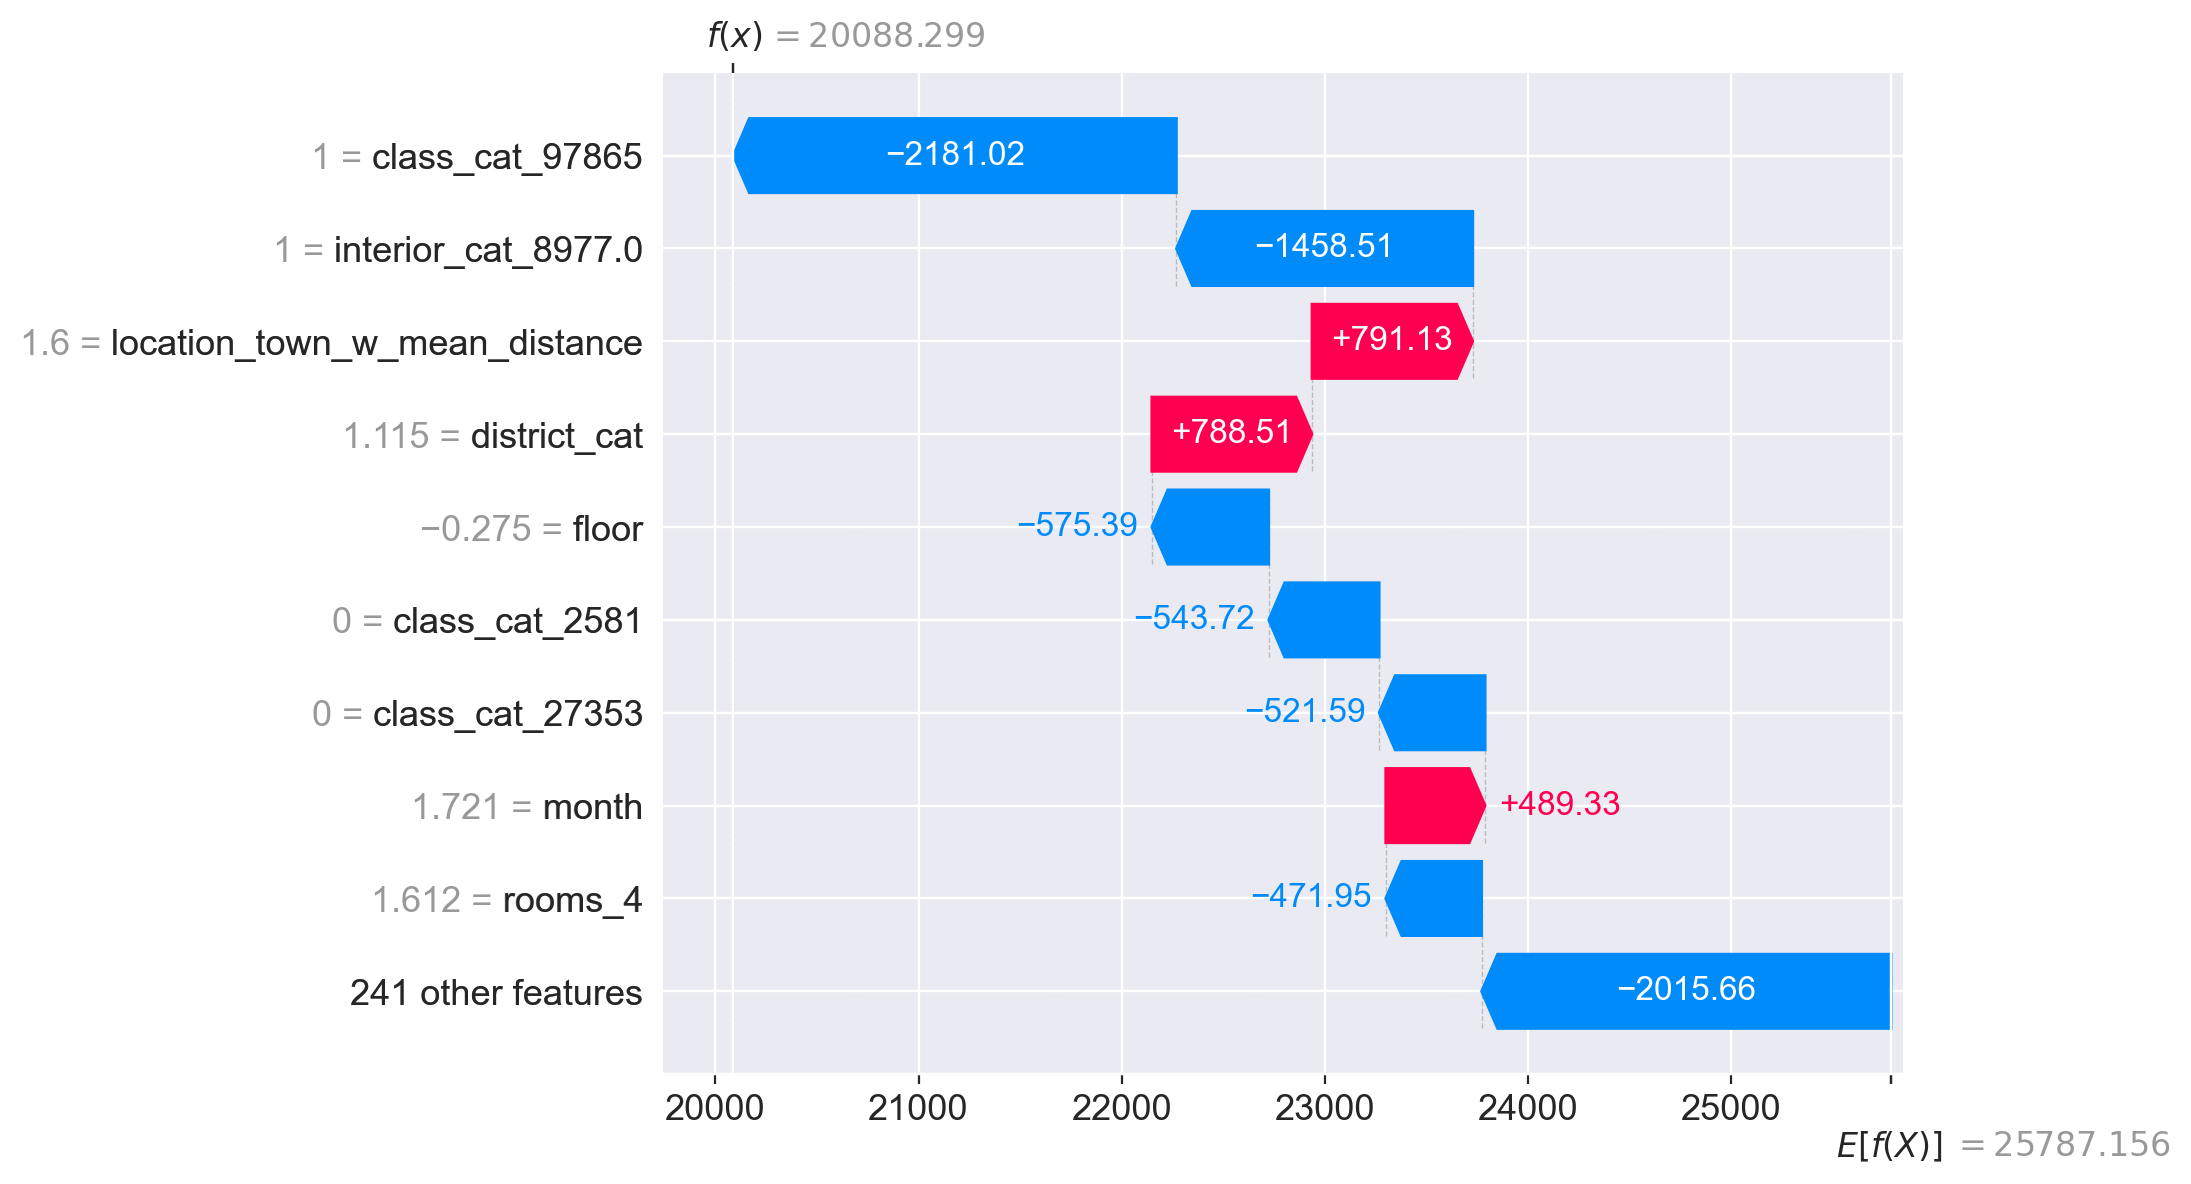

Linear Regression


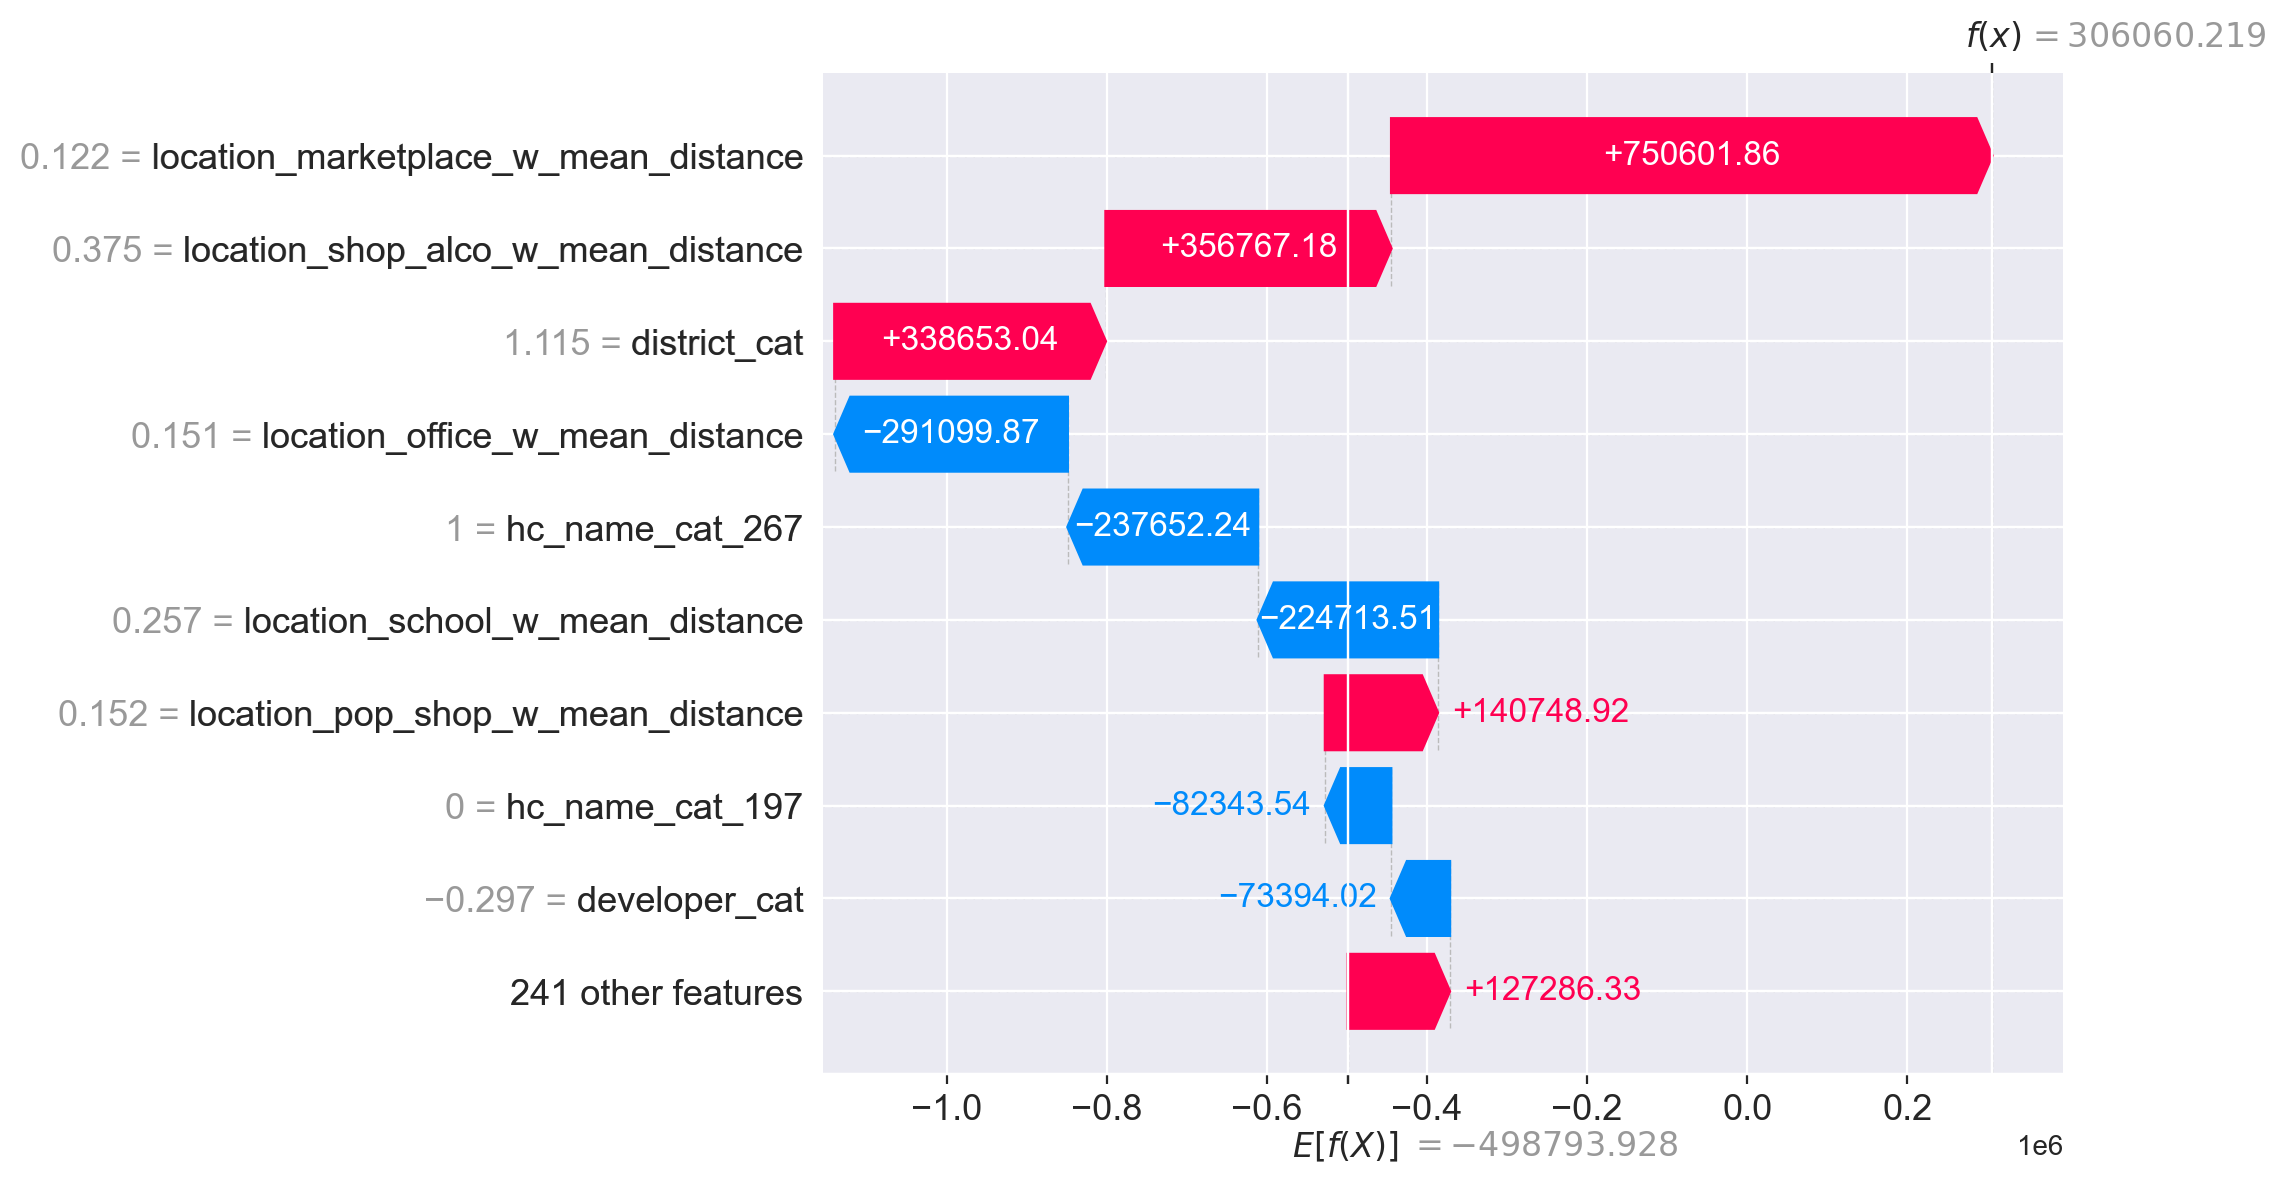

In [118]:
shap.initjs()

print("Gradient Boosting")
shap.plots.waterfall(shap_values_gb[0], max_display=10)

print("Linear Regression")
shap.plots.waterfall(shap_values_lr[0], max_display=10)

In [116]:
feature_names = get_feature_names(
    preprocessor_minmax,
    numerical_cols,
    categorical_cols
)

for cat_name in ['hc_name_cat', 'region_name_cat']:
    mask = [i for i, f in enumerate(feature_names) if cat_name in f]
    
    hc_contribution_gb = shap_values_gb.values[0, mask].sum()
    hc_contribution_lr = shap_values_lr.values[0, mask].sum()
    
    print(f"\nВклад {cat_name} в Gradient Boost: {hc_contribution_gb:.2f}")
    print(f"Вклад {cat_name} в Linear Regression: {hc_contribution_lr:.2f}")


Вклад hc_name_cat в Gradient Boost: -62.42
Вклад hc_name_cat в Linear Regression: -215588.65

Вклад region_name_cat в Gradient Boost: 225.21
Вклад region_name_cat в Linear Regression: 16217.27


In [117]:
pred_gb = boosting_model.predict(instance)[0]
shap_sum_gb = shap_values_gb.values[0].sum() + shap_values_gb.base_values[0]

print("Gradient Boost:", pred_gb, shap_sum_gb)


pred_lr = linear_model.predict(instance)[0]
shap_sum_lr = shap_values_lr.values[0].sum() + shap_values_lr.base_values[0]

print("Linear Regression:", pred_lr, shap_sum_lr)

Gradient Boost: 20088.29856349401 20088.29854941435
Linear Regression: 306060.2185828066 306060.21858280746
